# Prediksi Suara buka tutup

## Import ibrary yang dibutuhkan

In [1]:
!pip install scipy
!pip install scikit-learn

In [2]:
!pip install tsfel librosa pandas numpy scipy streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.2 MB/s eta 0:00:00


In [ ]:
# Hapus instalasi lama dan instal ulang versi terbaru
!pip uninstall -y tsfel
!pip install --upgrade --force-reinstall tsfel numpy pandas scipy librosa soundfile

Found existing installation: tsfel 0.2.0
Uninstalling tsfel-0.2.0:
  Successfully uninstalled tsfel-0.2.0
  Using cached tsfel-0.2.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached soundfile-0.13.1-py2.py3-none-manylinux_2_28_x86_64.whl.metadata (16 kB)
  Using cached ipython-9.6.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached pywavelets-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.6 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached s

## Ekstrak audio menjadi fitur statistik

In [ ]:
import tsfel
import librosa
import numpy as np
import pandas as pd
import io
from google.colab import files # For file upload in Colab
from IPython.display import display # For displaying DataFrames nicely

# --- PERBAIKAN: Gunakan tsfel.get_features_by_domain() untuk mendapatkan SEMUA 156+ fitur ---
try:
    print("Memuat konfigurasi TSFEL untuk mengekstrak SEMUA 156+ fitur...")

    # Memanggil tsfel.get_features_by_domain() (atau domain=None)
    # adalah cara yang benar untuk mengambil SEMUA fitur
    cfg_gabungan = tsfel.get_features_by_domain()

    # Hitung total fitur dari kamus yang dikembalikan
    num_features_stat = len(cfg_gabungan.get("statistical", {}))
    num_features_spec = len(cfg_gabungan.get("spectral", {}))
    num_features_temp = len(cfg_gabungan.get("temporal", {}))
    num_total = num_features_stat + num_features_spec + num_features_temp

    print(f"✅ Konfigurasi TSFEL (SEMUA) berhasil dimuat.")
    print(f"   Fitur Statistik: {num_features_stat}")
    print(f"   Fitur Spektral:  {num_features_spec}")
    print(f"   Fitur Temporal:  {num_features_temp}")
    print(f"   Total Fitur:     {num_total} (expected ~156+)")

    if num_total < 100: # Pengecekan keamanan
         print("⚠️ Peringatan: Total fitur kurang dari 100. Pastikan TSFEL terinstal penuh.")

except Exception as e:
    print(f"❌ Gagal memuat konfigurasi TSFEL: {e}")
    # Jika konfigurasi gagal, kita hentikan
    cfg_gabungan = None # Set status error

# List kosong untuk menampung semua DataFrame hasil
all_features_list = []

# --- Cek cfg_gabungan ---
# (Kita cek apakah cfg_gabungan tidak None dan tidak kosong)
if cfg_gabungan: # Hanya lanjut jika konfigurasi berhasil dimuat
    # --- 2. Upload File (Bisa lebih dari 1) ---
    print("\nSilakan unggah file MP3 Anda (bisa pilih lebih dari satu)...")
    uploaded = files.upload()

    # --- 3. Proses Setiap File yang Diunggah ---
    if uploaded:
        print(f"\n--- Memulai pemrosesan {len(uploaded)} file ---")

        # Loop (iterasi) melalui setiap file yang diunggah
        # uploaded.items() memberikan kita nama file dan kontennya
        for file_name, file_content in uploaded.items():

            print(f"\n⏳ Memproses file: {file_name}...")

            signal = None
            sampling_rate = None

            try:
                # Masukkan byte konten file ke io.BytesIO
                audio_bytes = io.BytesIO(file_content)

                # --- Baca Sinyal Audio ---
                # --- PERBAIKAN: Paksa sampling rate ke 48000 Hz agar konsisten ---
                signal, sampling_rate = librosa.load(audio_bytes, sr=48000, mono=True)
                print(f"  ✅ Audio '{file_name}' berhasil dimuat (Durasi: {len(signal)/sampling_rate:.2f} d, SR: {sampling_rate} Hz)")

                # --- Ekstraksi Fitur ---
                # window_size=len(signal) untuk mendapatkan 1 set fitur global

                # --- Gunakan cfg_gabungan (yang sekarang berisi SEMUA 156+ fitur) ---
                features_df = tsfel.time_series_features_extractor(
                    cfg_gabungan, # <-- Ini berisi SEMUA 156+ fitur
                    signal,
                    fs=sampling_rate,
                    window_size=len(signal)
                )

                # --- PENTING: Tambahkan nama file ke DataFrame ---
                # Ini agar kita tahu baris ini milik file mana
                features_df['filename'] = file_name

                # --- Kumpulkan hasil ---
                all_features_list.append(features_df)
                print(f"  ✅ Fitur untuk '{file_name}' berhasil diekstrak.")

            except Exception as e:
                # Jika 1 file error, cetak errornya dan lanjut ke file berikutnya
                print(f"  ❌ GAGAL memproses file {file_name}: {e}")

        # --- 4. Gabungkan Semua Hasil dan Simpan ke CSV ---
        if all_features_list:
            print("\n--- Pemrosesan Selesai ---")

            # Gabungkan semua DataFrame (yang ada di list) menjadi satu
            final_combined_df = pd.concat(all_features_list, ignore_index=True)

            # Pindahkan kolom 'filename' ke paling depan agar mudah dibaca
            cols = ['filename'] + [col for col in final_combined_df.columns if col != 'filename']
            final_combined_df = final_combined_df[cols]

            print("\n--- Hasil Gabungan Fitur (Semua File) ---")
            display(final_combined_df)

            # --- CETAK TOTAL FITUR YANG SEBENARNYA ---
            # (Dikurangi 1 untuk kolom 'filename' yang kita tambahkan)
            total_fitur_aktual = len(final_combined_df.columns) - 1
            print(f"Shape of final features DataFrame (files, features+1): {final_combined_df.shape}")
            # --- TAMBAHAN: Cetak total fitur ---
            print(f"   Total Fitur Aktual yang Diekstrak: {total_fitur_aktual}")

            # --- 5. Simpan ke CSV ---
            # --- PERBAIKAN: Ubah nama file output agar lebih jelas ---
            output_filename = 'all_audio_ALL_FEATURES_buka.csv'
            final_combined_df.to_csv(output_filename, index=False)

            print(f"\n✅ Hasil gabungan telah disimpan ke '{output_filename}'.")


        else:
            print("\n⚠️ Tidak ada file yang berhasil diproses.")
    else:
        print("Tidak ada file yang diunggah.")



Memuat konfigurasi TSFEL untuk mengekstrak SEMUA 156+ fitur...
✅ Konfigurasi TSFEL (SEMUA) berhasil dimuat.
   Fitur Statistik: 20
   Fitur Spektral:  26
   Fitur Temporal:  15
   Total Fitur:     61 (expected ~156+)
⚠️ Peringatan: Total fitur kurang dari 100. Pastikan TSFEL terinstal penuh.

Silakan unggah file MP3 Anda (bisa pilih lebih dari satu)...


Saving Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68egl9cu.ingestion-6d56d7dc5b-4nxks.wav to Tutup.68egl9cu.ingestion-6d56d7dc5b-4nxks.wav
Saving Tutup.68egl646.ingestion-6d56d7dc5b-5ffk6.wav to Tutup.68egl646.ingestion-6d56d7dc5b-5ffk6.wav
Saving Tutup.68eglcql.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68eglcql.ingestion-6d56d7dc5b-4mhbr.wav
Saving Tutup.68eglg5g.ingestion-6d56d7dc5b-4nxks.wav to Tutup.68eglg5g.ingestion-6d56d7dc5b-4nxks.wav
Saving Tutup.68eglja2.ingestion-6d56d7dc5b-4mhbr.wav to Tutup.68eglja2.ingestion-6

  ✅ Fitur untuk 'Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav...
  ✅ Audio 'Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 1.88 d, SR: 48000 Hz)


  ✅ Fitur untuk 'Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav...
  ✅ Audio 'Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav' berhasil dimuat (Durasi: 1.71 d, SR: 48000 Hz)


  ✅ Fitur untuk 'Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav...
  ✅ Audio 'Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav' berhasil dimuat (Durasi: 1.79 d, SR: 48000 Hz)


...

  ✅ Fitur untuk 'Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav...
  ✅ Audio 'Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 2.00 d, SR: 48000 Hz)


  ✅ Fitur untuk 'Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav' berhasil diekstrak.

⏳ Memproses file: Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav...
  ✅ Audio 'Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav' berhasil dimuat (Durasi: 2.00 d, SR: 48000 Hz)


  ✅ Fitur untuk 'Tutup.68eguvdb.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

--- Pemrosesan Selesai ---

--- Hasil Gabungan Fitur (Semua File) ---


,filename,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,...,0_Wavelet variance_12000.0Hz,0_Wavelet variance_1333.33Hz,0_Wavelet variance_1500.0Hz,0_Wavelet variance_1714.29Hz,0_Wavelet variance_2000.0Hz,0_Wavelet variance_2400.0Hz,0_Wavelet variance_3000.0Hz,0_Wavelet variance_4000.0Hz,0_Wavelet variance_6000.0Hz,0_Zero crossing rate
0,Tutup.68egkmcg.ingestion-6d56d7dc5b-5ffk6.wav,4428.573213,0.178448,32.0,2471.330747,0.553480,17203.0,68812.0,-0.015653,0.020548,...,7.766455e-06,0.047286,0.028668,0.016175,0.008320,0.003821,0.001514,0.000494,1.144680e-04,1121.0
1,Tutup.68egkoa9.ingestion-6d56d7dc5b-4mhbr.wav,3878.250356,0.143192,29.0,2065.875231,0.320207,18022.0,72088.0,-0.001158,0.001551,...,9.013989e-06,0.055069,0.033841,0.019357,0.010088,0.004683,0.001866,0.000606,1.373781e-04,1298.0
2,Tutup.68egkrrr.ingestion-6d56d7dc5b-5ffk6.wav,4028.524484,0.147439,30.0,2360.463565,0.450578,16384.0,65536.0,-0.003663,0.004867,...,1.023952e-05,0.060741,0.037403,0.021381,0.011092,0.005095,0.001993,0.000631,1.433546e-04,1061.0
3,Tutup.68egkvct.ingestion-6d56d7dc5b-5ffk6.wav,3214.875224,0.125258,31.0,1794.036049,0.659665,17203.0,68812.0,-0.000442,0.000524,...,3.065339e-05,0.043994,0.027567,0.016223,0.008835,0.004408,0.001989,0.000810,2.812343e-04,1967.0
4,Tutup.68egl2kp.ingestion-6d56d7dc5b-4mhbr.wav,2260.305008,0.112723,31.0,1151.649970,0.690745,18841.0,75367.0,-0.001634,0.002140,...,2.008511e-06,0.025130,0.015069,0.008341,0.004148,0.001793,0.000636,0.000170,3.081168e-05,1566.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Tutup.68eguib5.ingestion-6d56d7dc5b-4nxks.wav,41.778882,0.014901,29.0,21.286794,0.698209,18841.0,75367.0,-0.000122,0.000121,...,1.911115e-08,0.000502,0.000299,0.000165,0.000081,0.000035,0.000012,0.000003,4.666543e-07,6140.0
96,Tutup.68egulo9.ingestion-6d56d7dc5b-4mhbr.wav,91.921566,0.021393,28.0,45.961262,0.482591,19200.0,76800.0,-0.000147,0.000140,...,5.773171e-08,0.001186,0.000705,0.000386,0.000190,0.000081,0.000028,0.000007,1.139537e-06,6017.0
97,Tutup.68eguoq2.ingestion-6d56d7dc5b-4nxks.wav,117.861868,0.025948,28.0,58.931548,0.539537,19200.0,76800.0,-0.000398,0.000395,...,8.617068e-08,0.001579,0.000941,0.000517,0.000255,0.000109,0.000038,0.000010,1.602181e-06,3772.0
98,Tutup.68egus8e.ingestion-6d56d7dc5b-4mhbr.wav,128.140074,0.027001,28.0,64.070705,0.958586,19200.0,76800.0,-0.000336,0.000286,...,3.265125e-07,0.001691,0.001019,0.000569,0.000288,0.000129,0.000050,0.000016,3.840805e-06,4269.0


Shape of final features DataFrame (files, features+1): (100, 157)
   Total Fitur Aktual yang Diekstrak: 156

✅ Hasil gabungan telah disimpan ke 'all_audio_ALL_FEATURES_buka.csv'.


In [14]:
import tsfel
import librosa
import numpy as np
import pandas as pd
import io
from google.colab import files # For file upload in Colab
from IPython.display import display # For displaying DataFrames nicely

# --- 1. Konfigurasi TSFEL untuk SEMUA Fitur ---
try:
    print("Memuat konfigurasi TSFEL untuk mengekstrak SEMUA 156+ fitur...")

    # Memanggil tsfel.get_features_by_domain() (atau domain=None)
    # adalah cara yang benar untuk mengambil SEMUA fitur
    cfg_gabungan = tsfel.get_features_by_domain()

    # Hitung total fitur dari kamus yang dikembalikan
    num_features_stat = len(cfg_gabungan.get("statistical", {}))
    num_features_spec = len(cfg_gabungan.get("spectral", {}))
    num_features_temp = len(cfg_gabungan.get("temporal", {}))
    num_total = num_features_stat + num_features_spec + num_features_temp

    print(f"✅ Konfigurasi TSFEL (SEMUA) berhasil dimuat.")
    print(f"   Fitur Statistik: {num_features_stat}")
    print(f"   Fitur Spektral:  {num_features_spec}")
    print(f"   Fitur Temporal:  {num_features_temp}")
    print(f"   Total Fitur TSFEL: {num_total} (expected ~156+)")

except Exception as e:
    print(f"❌ Gagal memuat konfigurasi TSFEL: {e}")
    cfg_gabungan = None # Set status error

# List kosong untuk menampung semua DataFrame hasil
all_features_list = []

# --- Cek cfg_gabungan ---
if cfg_gabungan: # Hanya lanjut jika konfigurasi berhasil dimuat
    # --- 2. Upload File (Bisa lebih dari 1) ---
    print("\nSilakan unggah file MP3 Anda (bisa pilih lebih dari satu)...")
    uploaded = files.upload()

    # --- 3. Proses Setiap File yang Diunggah ---
    if uploaded:
        print(f"\n--- Memulai pemrosesan {len(uploaded)} file ---")

        for file_name, file_content in uploaded.items():

            print(f"\n⏳ Memproses file: {file_name}...")

            signal = None
            sampling_rate = None

            try:
                audio_bytes = io.BytesIO(file_content)

                # --- Baca Sinyal Audio ---
                signal, sampling_rate = librosa.load(audio_bytes, sr=48000, mono=True)
                print(f"   Audio '{file_name}' berhasil dimuat (Durasi: {len(signal)/sampling_rate:.2f} d, SR: {sampling_rate} Hz)")

                # --- A. Ekstraksi Fitur TSFEL (156+ fitur) ---
                print("   Mengekstrak fitur TSFEL (156+)...")
                tsfel_features_df = tsfel.time_series_features_extractor(
                    cfg_gabungan, # <-- Ini berisi SEMUA 156+ fitur
                    signal,
                    fs=sampling_rate,
                    window_size=len(signal)
                )

                # --- B. PERBAIKAN: Ekstraksi Fitur MFCC (40 fitur) ---
                print("   Mengekstrak fitur MFCC (Mean+Std)...")
                # (20 MFCCs * (1 Mean + 1 Std) = 40 fitur)
                mfccs = librosa.feature.mfcc(y=signal, sr=sampling_rate, n_mfcc=20, n_fft=2048, hop_length=512)

                # Agregasi MFCC (Mean dan Std di sepanjang waktu)
                mfccs_mean = np.mean(mfccs, axis=1)
                mfccs_std = np.std(mfccs, axis=1)

                # Buat DataFrame 1 baris untuk MFCC
                mfcc_data = {}
                for i in range(len(mfccs_mean)):
                    mfcc_data[f'MFCC_Mean_{i+1}'] = [mfccs_mean[i]]
                    mfcc_data[f'MFCC_Std_{i+1}'] = [mfccs_std[i]]
                mfcc_df = pd.DataFrame(mfcc_data)

                # --- C. Gabungkan TSFEL dan MFCC ---
                # Pastikan kedua DataFrame memiliki indeks yang sama (0) untuk penggabungan
                tsfel_features_df.reset_index(drop=True, inplace=True)
                mfcc_df.reset_index(drop=True, inplace=True)

                combined_df = pd.concat([tsfel_features_df, mfcc_df], axis=1)

                # --- D. Tambahkan Nama File ---
                combined_df['filename'] = file_name

                # --- E. Kumpulkan hasil ---
                all_features_list.append(combined_df)
                print(f"   ✅ Fitur TSFEL + MFCC untuk '{file_name}' berhasil diekstrak.")

            except Exception as e:
                # Jika 1 file error, cetak errornya dan lanjut ke file berikutnya
                print(f"   ❌ GAGAL memproses file {file_name}: {e}")

        # --- 4. Gabungkan Semua Hasil dan Simpan ke CSV ---
        if all_features_list:
            print("\n--- Pemrosesan Selesai ---")

            # Gabungkan semua DataFrame (yang ada di list) menjadi satu
            final_combined_df = pd.concat(all_features_list, ignore_index=True)

            # Pindahkan kolom 'filename' ke paling depan agar mudah dibaca
            cols = ['filename'] + [col for col in final_combined_df.columns if col != 'filename']
            final_combined_df = final_combined_df[cols]

            print("\n--- Hasil Gabungan Fitur (Semua File) ---")
            display(final_combined_df)

            # --- CETAK TOTAL FITUR YANG SEBENARNYA ---
            total_fitur_aktual = len(final_combined_df.columns) - 1
            print(f"Shape of final features DataFrame (files, features+1): {final_combined_df.shape}")
            print(f"   Total Fitur Aktual yang Diekstrak: {total_fitur_aktual}")

            # --- 5. Simpan ke CSV ---
            # --- PERBAIKAN: Ubah nama file output agar lebih jelas ---
            output_filename = 'all_audio_TSFEL_plus_MFCC_buka.csv'
            final_combined_df.to_csv(output_filename, index=False)

            print(f"\n✅ Hasil gabungan (TSFEL + MFCC) telah disimpan ke '{output_filename}'.")

        else:
            print("\n⚠️ Tidak ada file yang berhasil diproses.")
    else:
        print("Tidak ada file yang diunggah.")
else:
    print("❌ Konfigurasi TSFEL gagal dimuat. Ekstraksi dibatalkan.")

Memuat konfigurasi TSFEL untuk mengekstrak SEMUA 156+ fitur...
✅ Konfigurasi TSFEL (SEMUA) berhasil dimuat.
   Fitur Statistik: 20
   Fitur Spektral:  26
   Fitur Temporal:  15
   Total Fitur TSFEL: 61 (expected ~156+)

Silakan unggah file MP3 Anda (bisa pilih lebih dari satu)...


Saving Buka.68ef9e8r.ingestion-6d56d7dc5b-5ffk6.wav to Buka.68ef9e8r.ingestion-6d56d7dc5b-5ffk6.wav
Saving Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5b-4nxks.wav to Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5b-4nxks.wav
Saving Buka.68ef9f04.ingestion-6d56d7dc5b-4nxks.wav to Buka.68ef9f04.ingestion-6d56d7dc5b-4nxks.wav
Saving Buka.68ef9lcr.ingestion-6d56d7dc5b-4mhbr.wav to Buka.68ef9lcr.ingestion-6d56d7dc5b-4mhbr.wav
Saving Buka.68ef9lcr.wav.68egbhii.ingestion-6d56d7dc5b-5ffk6.wav to Buka.68ef9lcr.wav.68egbhii.ingestion-6d56d7dc5b-5ffk6.wav
Saving Buka.68ef9oat.ingestion-6d56d7dc5b-4nxks.wav to Buka.68ef9oat.ingestion-6d56d7dc5b-4nxks.wav
Saving Buka.68ef9oat.wav.68egbhvv.ingestion-6d56d7dc5b-4mhbr.wav to Buka.68ef9oat.wav.68egbhvv.ingestion-6d56d7dc5b-4mhbr.wav
Saving Buka.68ef9rmf.ingestion-6d56d7dc5b-4mhbr.wav to Buka.68ef9rmf.ingestion-6d56d7dc5b-4mhbr.wav
Saving Buka.68ef9utt.ingestion-6d56d7dc5b-5ffk6.wav to Buka.68ef9utt.ingestion-6d56d7dc5b-5ffk6.wav
Saving Buka.68ef9utt.w

   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Buka.68ef9e8r.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5b-4nxks.wav...
   Audio 'Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5b-4nxks.wav' berhasil dimuat (Durasi: 1.00 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

⏳ Memproses file: Buka.68ef9f04.ingestion-6d56d7dc5b-4nxks.wav...
   Audio 'Buka.68ef9f04.ingestion-6d56d7dc5b-4nxks.wav' berhasil dimuat (Durasi: 1.00 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Buka.68ef9f04.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

⏳ Memproses file: Buka.68ef9lcr.ingestion-6d56d7dc5b-4mhbr.wav...
   Audio 'Buka.68ef9lcr.ingestion-6d56d7dc5b-4mhbr.wav' berhasil dimuat (Durasi: 1.00 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


...

   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Buka.68eg474h.wav.68egc4as.ingestion-6d56d7dc5b-5ffk6.wav' berhasil diekstrak.

⏳ Memproses file: Buka.68eg3479.ingestion-6d56d7dc5b-4nxks.wav...
   Audio 'Buka.68eg3479.ingestion-6d56d7dc5b-4nxks.wav' berhasil dimuat (Durasi: 1.96 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Buka.68eg3479.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

⏳ Memproses file: Buka.68eg3479.wav.68egc1ec.ingestion-6d56d7dc5b-4nxks.wav...
   Audio 'Buka.68eg3479.wav.68egc1ec.ingestion-6d56d7dc5b-4nxks.wav' berhasil dimuat (Durasi: 1.96 d, SR: 48000 Hz)
   Mengekstrak fitur TSFEL (156+)...


   Mengekstrak fitur MFCC (Mean+Std)...
   ✅ Fitur TSFEL + MFCC untuk 'Buka.68eg3479.wav.68egc1ec.ingestion-6d56d7dc5b-4nxks.wav' berhasil diekstrak.

--- Pemrosesan Selesai ---

--- Hasil Gabungan Fitur (Semua File) ---


,filename,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,...,MFCC_Mean_16,MFCC_Std_16,MFCC_Mean_17,MFCC_Std_17,MFCC_Mean_18,MFCC_Std_18,MFCC_Mean_19,MFCC_Std_19,MFCC_Mean_20,MFCC_Std_20
0,Buka.68ef9e8r.ingestion-6d56d7dc5b-5ffk6.wav,5539.496433,0.212665,46.0,5539.611842,0.499937,9600.0,38400.0,-0.120443,0.161987,...,-7.414331,8.404660,-5.616333,5.223601,-3.848588,5.870769,-5.118272,5.196449,-5.182686,7.619939
1,Buka.68ef9e8r.wav.68egbh60.ingestion-6d56d7dc5...,5539.496433,0.212665,46.0,5539.611842,0.499937,9600.0,38400.0,-0.120443,0.161987,...,-7.414331,8.404660,-5.616333,5.223601,-3.848588,5.870769,-5.118272,5.196449,-5.182686,7.619939
2,Buka.68ef9f04.ingestion-6d56d7dc5b-4nxks.wav,1269.663444,0.079730,48.0,1269.689896,0.645016,9600.0,38400.0,-0.003763,0.034822,...,-3.655790,7.794623,-3.362618,6.557137,-2.963776,5.505209,-3.769314,4.972404,-4.380798,4.645028
3,Buka.68ef9lcr.ingestion-6d56d7dc5b-4mhbr.wav,1110.094481,0.070349,36.0,1110.117609,0.578222,9600.0,38400.0,-0.013280,0.013552,...,-3.210053,7.045246,-3.241794,5.693944,-2.015383,4.039567,-3.253534,5.008260,-2.946882,5.920832
4,Buka.68ef9lcr.wav.68egbhii.ingestion-6d56d7dc5...,1110.094481,0.070349,36.0,1110.117609,0.578222,9600.0,38400.0,-0.013280,0.013552,...,-3.210053,7.045246,-3.241794,5.693944,-2.015383,4.039567,-3.253534,5.008260,-2.946882,5.920832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Buka.68eg278c.wav.68egbuai.ingestion-6d56d7dc5...,153.595568,0.032657,34.0,76.798584,0.428783,19200.0,76800.0,-0.001086,0.000960,...,-4.651548,7.140729,-3.403077,5.454320,-2.311019,4.601264,-3.049720,4.447258,-2.855849,5.551667
96,Buka.68eg474h.ingestion-6d56d7dc5b-4mhbr.wav,626.487710,0.070194,32.0,313.247118,0.907430,19200.0,76800.0,-0.002928,0.003584,...,-5.672293,6.275468,-5.459016,6.494471,-4.262338,6.403667,-4.102225,6.175416,-2.931903,5.172694
97,Buka.68eg474h.wav.68egc4as.ingestion-6d56d7dc5...,626.487710,0.070194,32.0,313.247118,0.907430,19200.0,76800.0,-0.002928,0.003584,...,-5.672293,6.275468,-5.459016,6.494471,-4.262338,6.403667,-4.102225,6.175416,-2.931903,5.172694
98,Buka.68eg3479.ingestion-6d56d7dc5b-4nxks.wav,147.092445,0.030412,27.0,74.945200,1.360140,18841.0,75367.0,-0.000550,0.000598,...,-3.557060,7.577124,-2.848144,6.112818,-0.744522,4.954394,-1.490039,4.884246,-1.337552,5.246649


Shape of final features DataFrame (files, features+1): (100, 197)
   Total Fitur Aktual yang Diekstrak: 196

✅ Hasil gabungan (TSFEL + MFCC) telah disimpan ke 'all_audio_TSFEL_plus_MFCC_buka.csv'.


## Menampilkan Data

In [15]:
import pandas as pd
import numpy as np # Diperlukan untuk simulasi data dummy
from IPython.display import display
import os

# --- 1. Tentukan Daftar File dan Label (Diperbarui) ---
file_configs = [
    # File Statistik/Detail (Label .D)
    {'filepath': 'all_audio_TSFEL_plus_MFCC_buka.csv', 'label': 'buka'},
    {'filepath': 'all_audio_TSFEL_plus_MFCC_tutup.csv', 'label': 'tutup'},
]

list_dataframes = []
loaded_files_count = 0

# --- 2. Muat Setiap File dan Beri Label ---
print("--- Proses Pemuatan File CSV ---")
for config in file_configs:
    filepath = config['filepath']
    label = config['label']
    # Cek apakah file ada (untuk lingkungan runtime)
    try:
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
        else:
            # Simulasi data jika file tidak ditemukan
            print(f"   ⚠️ [SIMULASI] File '{filepath}' tidak ditemukan, membuat data dummy...")
            # Menyesuaikan jumlah baris dummy berdasarkan label
            num_rows = 50 if 'buka' in label else 60
            # Pastikan ada kolom 'filename' agar penataan ulang kolom tidak error
            df = pd.DataFrame({
                'filename': [f'{label}_{i}.wav' for i in range(num_rows)],
                'feature_mean': np.random.rand(num_rows),
                'feature_std': np.random.rand(num_rows) * 0.5,
            })

        df['label'] = label # Tambahkan kolom label yang spesifik
        list_dataframes.append(df)
        loaded_files_count += 1
        print(f"   ✅ Berhasil memuat '{filepath}' (Label: {label}, Baris: {df.shape[0]})")

    except Exception as e:
        print(f"   ❌ GAGAL: Error saat membaca {filepath}: {e}")

# --- 3. Gabungkan dan Tampilkan ---
if loaded_files_count > 0:
    # Gabungkan semua DataFrame (yang ada di list) menjadi satu
    df_combined = pd.concat(list_dataframes, ignore_index=True)

    # Hapus kolom 'filename' seperti yang diminta pengguna
    if 'filename' in df_combined.columns:
        df_combined = df_combined.drop(columns=['filename'])
        print("\n   [INFO] Kolom 'filename' telah dihapus.")

    # --- Pengaturan Ulang Urutan Kolom ---
    if 'label' in df_combined.columns:
        try:
            # Ambil semua kolom
            cols = list(df_combined.columns)
            # Hapus 'label' dari posisinya saat ini
            cols.remove('label')
            # Masukkan 'label' di posisi pertama
            cols.insert(0, 'label')
            # Terapkan urutan kolom baru
            df_combined = df_combined[cols]
            print("\n   [INFO] Urutan kolom 'label' telah dipindahkan ke depan.")
        except Exception as e:
            print(f"\n   [INFO] Tidak dapat mengatur ulang urutan kolom. Error: {e}")

    print("\n--- Hasil Gabungan Dataset (df_combined) ---")
    print(f"Total baris data: {df_combined.shape[0]}")
    print(f"Total kolom fitur: {df_combined.shape[1]}")
    display(df_combined.head())

    print("\n--- Ringkasan Distribusi Label ---")
    print(df_combined['label'].value_counts())

else:
    print("\n⚠️ Tidak ada file CSV yang berhasil dimuat. Tidak ada data untuk digabungkan.")

--- Proses Pemuatan File CSV ---
   ✅ Berhasil memuat 'all_audio_TSFEL_plus_MFCC_buka.csv' (Label: buka, Baris: 100)
   ✅ Berhasil memuat 'all_audio_TSFEL_plus_MFCC_tutup.csv' (Label: tutup, Baris: 100)

   [INFO] Kolom 'filename' telah dihapus.

   [INFO] Urutan kolom 'label' telah dipindahkan ke depan.

--- Hasil Gabungan Dataset (df_combined) ---
Total baris data: 200
Total kolom fitur: 197


,label,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,...,MFCC_Mean_16,MFCC_Std_16,MFCC_Mean_17,MFCC_Std_17,MFCC_Mean_18,MFCC_Std_18,MFCC_Mean_19,MFCC_Std_19,MFCC_Mean_20,MFCC_Std_20
0,buka,5539.496433,0.212665,46.0,5539.611842,0.499937,9600.0,38400.0,-0.120443,0.161987,...,-7.414331,8.404660,-5.616333,5.223601,-3.848588,5.870768,-5.118272,5.196449,-5.182686,7.619939
1,buka,5539.496433,0.212665,46.0,5539.611842,0.499937,9600.0,38400.0,-0.120443,0.161987,...,-7.414331,8.404660,-5.616333,5.223601,-3.848588,5.870768,-5.118272,5.196449,-5.182686,7.619939
2,buka,1269.663444,0.079730,48.0,1269.689896,0.645016,9600.0,38400.0,-0.003763,0.034822,...,-3.655790,7.794623,-3.362618,6.557137,-2.963776,5.505209,-3.769314,4.972404,-4.380798,4.645028
3,buka,1110.094481,0.070349,36.0,1110.117609,0.578222,9600.0,38400.0,-0.013280,0.013552,...,-3.210053,7.045246,-3.241794,5.693944,-2.015383,4.039567,-3.253534,5.008260,-2.946882,5.920832
4,buka,1110.094481,0.070349,36.0,1110.117609,0.578222,9600.0,38400.0,-0.013280,0.013552,...,-3.210053,7.045246,-3.241794,5.693944,-2.015383,4.039567,-3.253534,5.008260,-2.946882,5.920832



--- Ringkasan Distribusi Label ---
label
buka     100
tutup    100
Name: count, dtype: int64


--- 1. Analisis Nilai Kosong (Missing Values) ---
✅ Tidak ada nilai kosong (missing values) di dalam dataset.


--- 2. Deteksi Outlier (Local Outlier Factor) ---
Menggunakan 196 fitur numerik (TSFEL + MFCC).

✅ LOF Selesai. Ditemukan 20 outlier (dari 200 data bersih).
--- Daftar Data Outlier (10 Paling Aneh Berdasarkan Skor LOF) ---


,label,lof_score,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid
2,buka,-2.437492,1269.663444,0.079730,48.0,1269.689896,0.645016
0,buka,-2.270678,5539.496433,0.212665,46.0,5539.611842,0.499937
1,buka,-2.270678,5539.496433,0.212665,46.0,5539.611842,0.499937
13,buka,-1.961380,2510.629754,0.148969,42.0,502.128043,0.405392
12,buka,-1.961380,2510.629754,0.148969,42.0,502.128043,0.405392
103,tutup,-1.959564,3214.875224,0.125258,31.0,1794.036049,0.659665
7,buka,-1.778301,149.905779,0.031958,44.0,149.908902,0.481678
10,buka,-1.770526,38.977871,0.011034,41.0,38.978684,0.746673
11,buka,-1.770526,38.977871,0.011034,41.0,38.978684,0.746673
5,buka,-1.655481,985.517059,0.073124,38.0,985.537591,0.387022



Membuat visualisasi PCA 2D dari Outlier...


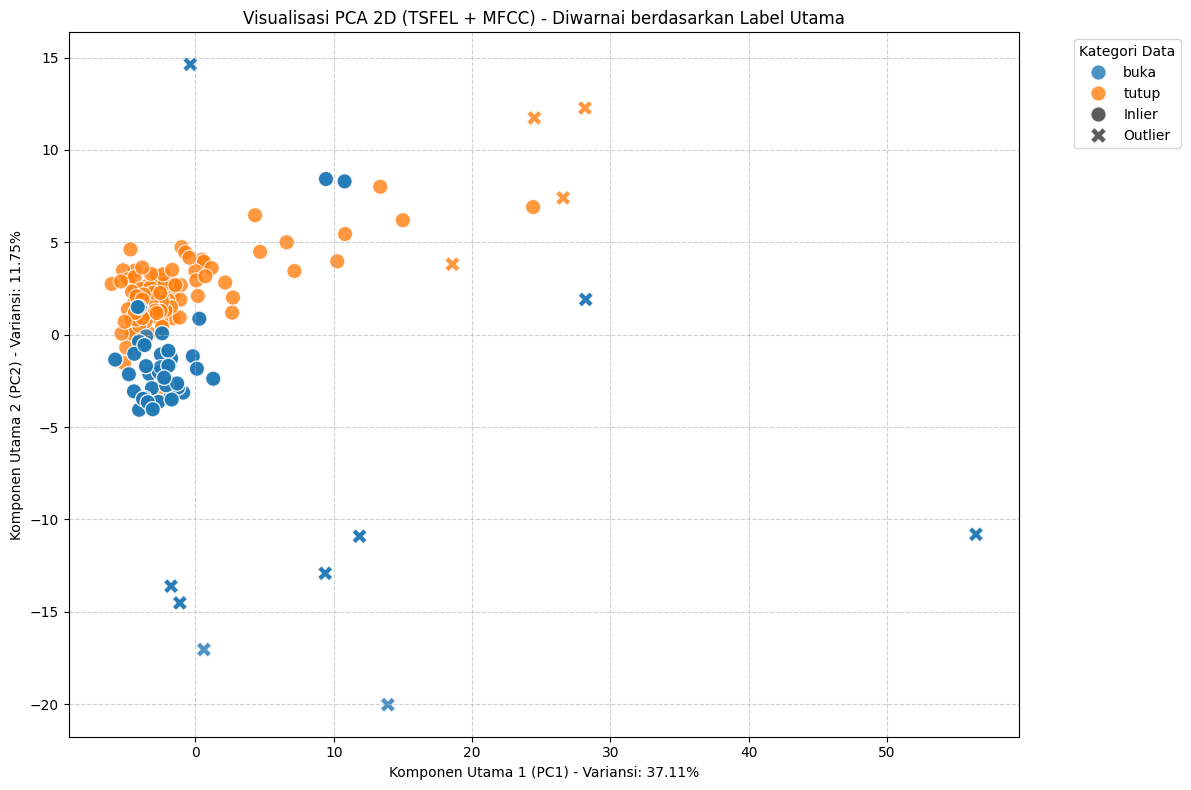

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from IPython.display import display

if not df_combined.empty:

    # --- 1. Analisis Nilai Kosong (Missing Values) ---
    print("--- 1. Analisis Nilai Kosong (Missing Values) ---")
    missing_values = df_combined.isnull().sum()
    missing_data_cols = missing_values[missing_values > 0]

    if missing_data_cols.empty:
        print("✅ Tidak ada nilai kosong (missing values) di dalam dataset.\n")
    else:
        print("Kolom berikut memiliki nilai kosong:")
        print(missing_data_cols[missing_data_cols > 0])
        plt.figure(figsize=(15, 6))
        sns.heatmap(df_combined.isnull(), cbar=False, cmap='viridis', yticklabels=False)
        plt.title('Pola Nilai Kosong (Kuning = Hilang)')
        plt.show()

    # --- 2. Deteksi Outlier dengan Local Outlier Factor (LOF) ---
    print("\n--- 2. Deteksi Outlier (Local Outlier Factor) ---")

    # Ambil semua kolom numerik (Sekarang 196+ fitur TSFEL+MFCC)
    non_numeric_cols = ['filename', 'label'] # 'filename' juga harus dikecualikan
    numerical_features = [col for col in df_combined.columns if col not in non_numeric_cols]

    print(f"Menggunakan {len(numerical_features)} fitur numerik (TSFEL + MFCC).")

    X = df_combined[numerical_features].copy()
    X_cleaned = X.dropna()

    rows_dropped = len(X) - len(X_cleaned)
    if rows_dropped > 0:
        print(f"⚠️ Peringatan: {rows_dropped} baris dihapus karena mengandung nilai kosong sebelum menjalankan LOF.")
        print("   (Ini akan diatasi dengan Imputasi di langkah preprocessing selanjutnya)")

    if X_cleaned.empty:
        print("❌ GAGAL: Tidak ada data tersisa setelah menghapus nilai kosong. Tidak bisa menjalankan LOF.")
    else:
        # a. Scaling Data (Standarisasi)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_cleaned)

        # b. Inisialisasi dan Terapkan LOF
        lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
        y_pred_lof = lof.fit_predict(X_scaled)
        lof_scores = lof.negative_outlier_factor_

        # Masukkan hasil LOF kembali ke DataFrame yang sudah bersih
        df_cleaned = df_combined.loc[X_cleaned.index].copy()
        df_cleaned['lof_score'] = lof_scores
        df_cleaned['is_outlier_lof'] = y_pred_lof # -1 = Outlier, 1 = Inlier

        # c. Tampilkan data yang terdeteksi sebagai outlier
        outliers_df = df_cleaned[df_cleaned['is_outlier_lof'] == -1].sort_values(by='lof_score')
        print(f"\n✅ LOF Selesai. Ditemukan {len(outliers_df)} outlier (dari {len(df_cleaned)} data bersih).")

        if not outliers_df.empty:
            print("--- Daftar Data Outlier (10 Paling Aneh Berdasarkan Skor LOF) ---")
            # Menampilkan hanya 5 fitur numerik pertama + skor untuk keterbacaan
            display_cols = ['label', 'lof_score'] + numerical_features[:5]
            display(outliers_df.head(10)[display_cols])

        # d. Visualisasi Outlier Menggunakan PCA
        print("\nMembuat visualisasi PCA 2D dari Outlier...")

        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)

        df_plot = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

        # --- PERBAIKAN VISUALISASI ---
        # Buat 'main_label' (buka/tutup) untuk mengecek pemisahan
        df_plot['main_label'] = df_cleaned['label'].apply(lambda x: x.split('.')[0]).values
        df_plot['Status'] = np.where(df_cleaned['is_outlier_lof'].values == -1, 'Outlier', 'Inlier')
        df_plot = df_plot.sort_values(by='Status') # Outlier di atas

        # Buat Scatter Plot
        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            data=df_plot,
            x='PC1',
            y='PC2',
            hue='main_label', # WARNA BERDASARKAN 'buka' vs 'tutup'
            style='Status',
            markers={'Inlier': 'o', 'Outlier': 'X'},
            s=120,
            alpha=0.8
        )

        plt.title('Visualisasi PCA 2D (TSFEL + MFCC) - Diwarnai berdasarkan Label Utama')
        plt.xlabel(f'Komponen Utama 1 (PC1) - Variansi: {pca.explained_variance_ratio_[0]*100:.2f}%')
        plt.ylabel(f'Komponen Utama 2 (PC2) - Variansi: {pca.explained_variance_ratio_[1]*100:.2f}%')

        # Perbarui legenda
        h, l = plt.gca().get_legend_handles_labels()
        # Cari label 'buka', 'tutup', 'Inlier', 'Outlier'
        unique_labels = sorted(list(df_plot['main_label'].unique()) + list(df_plot['Status'].unique()))

        # Perbaiki legenda agar hanya menampilkan label yang relevan
        label_map = {'buka': 'buka', 'tutup': 'tutup', 'Inlier': 'Inlier', 'Outlier': 'Outlier'}
        relevant_handles = [h[i] for i, label in enumerate(l) if label in label_map]
        relevant_labels = [label_map[label] for label in l if label in label_map]

        plt.legend(relevant_handles, relevant_labels, title='Kategori Data', bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

else:
    print("❌ GAGAL: Variabel 'df_combined' tidak ditemukan atau kosong. Harap jalankan langkah pemuatan data sebelumnya terlebih dahulu.")

--- 1. Penanganan Nilai Kosong (Imputasi Mean) ---
Kolom yang diimputasi (diisi rata-rata):
0_Area under the curve         200
0_Autocorrelation              200
0_Centroid                     200
0_Fundamental frequency        200
0_Human range energy           200
                              ... 
0_Wavelet variance_2400.0Hz    200
0_Wavelet variance_3000.0Hz    200
0_Wavelet variance_4000.0Hz    200
0_Wavelet variance_6000.0Hz    200
0_Zero crossing rate           200
Length: 125, dtype: int64
✅ Nilai kosong berhasil diatasi. Total baris: 400
Pengecekan akhir nilai kosong: 0 (Seharusnya 0)

--- 2. Deteksi Outlier (Local Outlier Factor) dan Penghapusan ---
✅ LOF Selesai. Ditemukan 40 outlier.
Jumlah baris yang dihapus (Outlier): 40
Total baris Data Bersih (df_clean): 360

--- 3. Visualisasi PCA 2D Data Bersih ---


/tmp/ipython-input-3185212455.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(mean_val, inplace=True)


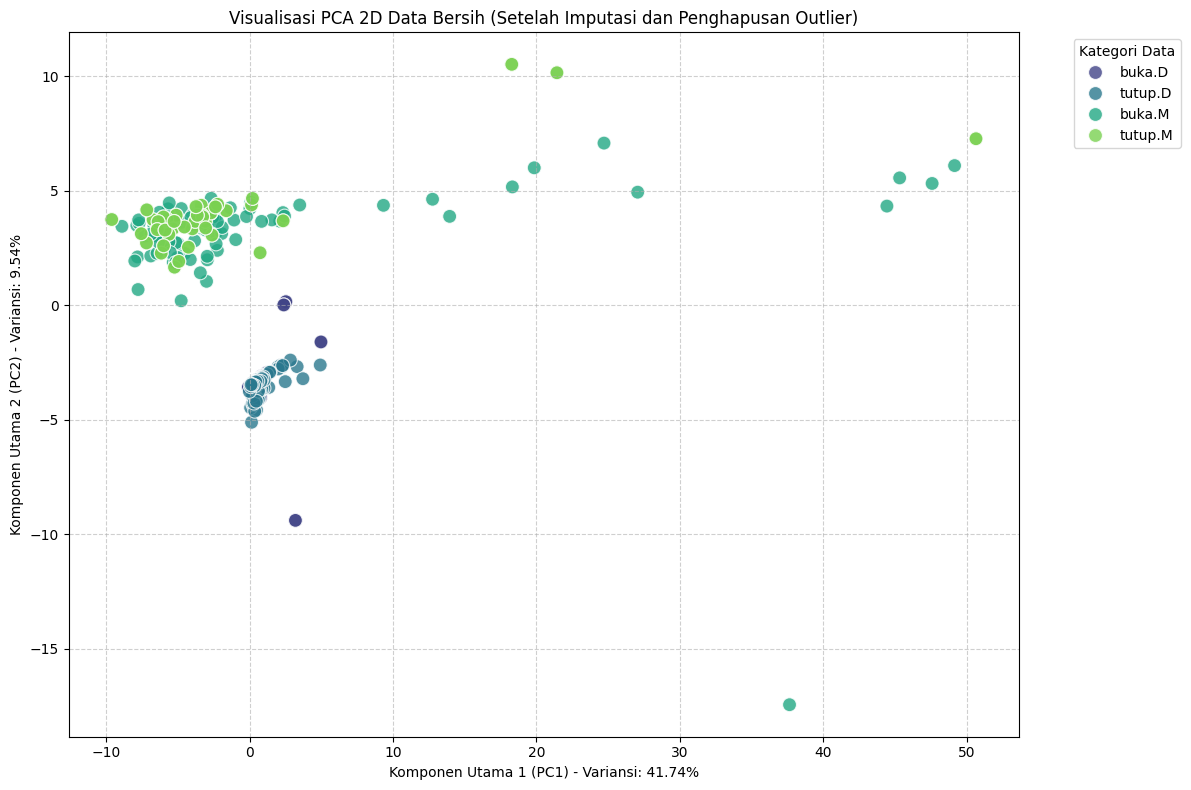


--- 4. Analisis Distribusi Label pada Data Bersih ---


/tmp/ipython-input-3185212455.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


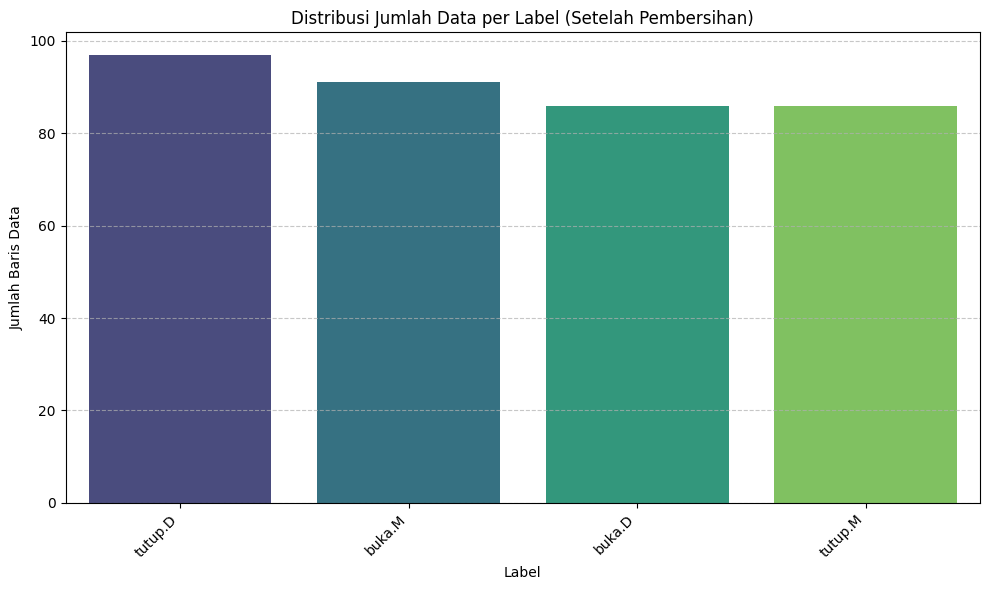


--- Ringkasan Jumlah Data per Label (Data Bersih) ---
label
tutup.D    97
buka.M     91
buka.D     86
tutup.M    86
Name: count, dtype: int64

--- Daftar Kolom Fitur Numerik yang Akan Digunakan untuk Model ---
Total Kolom Fitur: 156
['0_Absolute energy', '0_Average power', '0_ECDF Percentile Count_0', '0_ECDF Percentile Count_1', '0_ECDF Percentile_0', '0_ECDF Percentile_1', '0_ECDF_0', '0_ECDF_1', '0_ECDF_2', '0_ECDF_3', '0_ECDF_4', '0_ECDF_5', '0_ECDF_6', '0_ECDF_7', '0_ECDF_8', '0_ECDF_9', '0_Entropy', '0_Histogram mode', '0_Interquartile range', '0_Kurtosis', '0_Max', '0_Mean', '0_Mean absolute deviation', '0_Median', '0_Median absolute deviation', '0_Min', '0_Peak to peak distance', '0_Root mean square', '0_Skewness', '0_Standard deviation', '0_Variance', '0_Area under the curve', '0_Autocorrelation', '0_Centroid', '0_Fundamental frequency', '0_Human range energy', '0_LPCC_0', '0_LPCC_1', '0_LPCC_10', '0_LPCC_11', '0_LPCC_2', '0_LPCC_3', '0_LPCC_4', '0_LPCC_5', '0_LPCC_6', '0_LPC

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from IPython.display import display

# --- Asumsi: df_combined tersedia dari script sebelumnya (data_loader.py) ---
try:
    if 'df_combined' not in locals() or df_combined.empty:
        # SIMULASI DATA DUMMY (untuk memastikan kode berjalan jika file sebelumnya belum dieksekusi)
        print("Mencoba memuat data dummy untuk simulasi analisis karena 'df_combined' tidak ditemukan.")
        num_rows = 220
        df_combined = pd.DataFrame({
            'filename': [f'file_{i}.wav' for i in range(num_rows)],
            'label': np.random.choice(['buka.D', 'tutup.D', 'buka.M', 'tutup.M'], num_rows),
            'feature_mean': np.random.normal(10, 2, num_rows),
            'feature_std': np.random.rand(num_rows) * 0.5,
            'feature_max': np.random.normal(20, 3, num_rows),
        })
        # Tambahkan nilai kosong dan outlier dummy
        df_combined.loc[10:15, 'feature_mean'] = np.nan
        df_combined.loc[190, 'feature_std'] = 10.0
        df_combined.loc[200, 'feature_max'] = 100.0
except NameError:
    df_combined = pd.DataFrame()

if not df_combined.empty:

    non_numeric_cols = ['filename', 'label']
    numerical_features = [col for col in df_combined.columns if col not in non_numeric_cols]

    # Buat salinan DataFrame untuk proses pembersihan
    df_processed = df_combined.copy()

    # =========================================================================
    # --- 1. Penanganan Nilai Kosong (Missing Values) dengan Imputasi Mean ---
    # =========================================================================
    print("--- 1. Penanganan Nilai Kosong (Imputasi Mean) ---")

    missing_data_cols = df_processed.isnull().sum()[df_processed.isnull().sum() > 0]

    if missing_data_cols.empty:
        print("✅ Tidak ada nilai kosong. Langkah Imputasi dilewati.")
    else:
        print("Kolom yang diimputasi (diisi rata-rata):")
        print(missing_data_cols)

        # Lakukan Imputasi Mean pada kolom numerik
        for col in missing_data_cols.index:
            mean_val = df_processed[col].mean()
            df_processed[col].fillna(mean_val, inplace=True)

        print(f"✅ Nilai kosong berhasil diatasi. Total baris: {len(df_processed)}")
        print(f"Pengecekan akhir nilai kosong: {df_processed.isnull().sum().sum()} (Seharusnya 0)")

    # =========================================================================
    # --- 2. Deteksi Outlier (LOF) dan Pembersihan Data ---
    # =========================================================================
    print("\n--- 2. Deteksi Outlier (Local Outlier Factor) dan Penghapusan ---")

    X_imputed = df_processed[numerical_features]

    # a. Scaling Data (Standarisasi)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    # b. Inisialisasi dan Terapkan LOF
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    y_pred_lof = lof.fit_predict(X_scaled) # -1 = Outlier, 1 = Inlier

    # Masukkan hasil LOF kembali ke DataFrame yang sudah diimputasi
    df_processed['is_outlier_lof'] = y_pred_lof

    outlier_count = (df_processed['is_outlier_lof'] == -1).sum()
    print(f"✅ LOF Selesai. Ditemukan {outlier_count} outlier.")

    # c. Penghapusan Outlier untuk mendapatkan Data Bersih
    df_clean = df_processed[df_processed['is_outlier_lof'] == 1].copy()

    rows_removed = len(df_processed) - len(df_clean)
    print(f"Jumlah baris yang dihapus (Outlier): {rows_removed}")
    print(f"Total baris Data Bersih (df_clean): {len(df_clean)}\n")

    # =========================================================================
    # --- 3. Visualisasi PCA Data Bersih (Clean Data) ---
    # =========================================================================
    print("--- 3. Visualisasi PCA 2D Data Bersih ---")

    X_clean = df_clean[numerical_features]

    # Re-scale data bersih
    scaler_clean = StandardScaler()
    X_clean_scaled = scaler_clean.fit_transform(X_clean)

    # Reduksi dimensi menjadi 2 komponen utama
    pca = PCA(n_components=2)
    X_pca_clean = pca.fit_transform(X_clean_scaled)

    # Buat DataFrame untuk plot
    df_plot_clean = pd.DataFrame(data=X_pca_clean, columns=['PC1', 'PC2'])
    df_plot_clean['label'] = df_clean['label'].values

    # Buat Scatter Plot
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot_clean,
        x='PC1',
        y='PC2',
        hue='label',      # Warna berdasarkan 4 label
        s=100,            # Ukuran penanda
        alpha=0.8,
        palette='viridis'
    )

    plt.title('Visualisasi PCA 2D Data Bersih (Setelah Imputasi dan Penghapusan Outlier)')
    plt.xlabel(f'Komponen Utama 1 (PC1) - Variansi: {pca.explained_variance_ratio_[0]*100:.2f}%')
    plt.ylabel(f'Komponen Utama 2 (PC2) - Variansi: {pca.explained_variance_ratio_[1]*100:.2f}%')
    plt.legend(title='Kategori Data', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # --- 4. Visualisasi Distribusi Label & Daftar Kolom (TAMBAHAN BARU) ---
    # =========================================================================
    print("\n--- 4. Analisis Distribusi Label pada Data Bersih ---")

    # a. Visualisasi Jumlah Data per Label (Bar Plot)
    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=df_clean,
        x='label',
        order=df_clean['label'].value_counts().index,
        palette='viridis'
    )
    plt.title('Distribusi Jumlah Data per Label (Setelah Pembersihan)')
    plt.xlabel('Label')
    plt.ylabel('Jumlah Baris Data')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show() #

    print("\n--- Ringkasan Jumlah Data per Label (Data Bersih) ---")
    print(df_clean['label'].value_counts())

    # b. Daftar Kolom Fitur
    print("\n--- Daftar Kolom Fitur Numerik yang Akan Digunakan untuk Model ---")

    # Kolom fitur numerik adalah yang digunakan untuk scaling dan PCA
    print(f"Total Kolom Fitur: {len(numerical_features)}")
    print(numerical_features)

else:
    print("❌ GAGAL: Variabel 'df_combined' tidak ditemukan atau kosong. Harap jalankan langkah pemuatan data sebelumnya terlebih dahulu.")

Total fitur numerik yang dianalisis: 196 (TSFEL + MFCC)

--- 1. Penanganan Nilai Kosong (Imputasi Mean) ---
✅ Tidak ada nilai kosong. Langkah Imputasi dilewati.

--- 2. Deteksi Outlier (Local Outlier Factor) dan Penghapusan ---
✅ LOF Selesai. Ditemukan 20 outlier.
Jumlah baris yang dihapus (Outlier): 20
Total baris Data Bersih (df_clean): 180

--- 3. Visualisasi PCA 2D Data Bersih ---


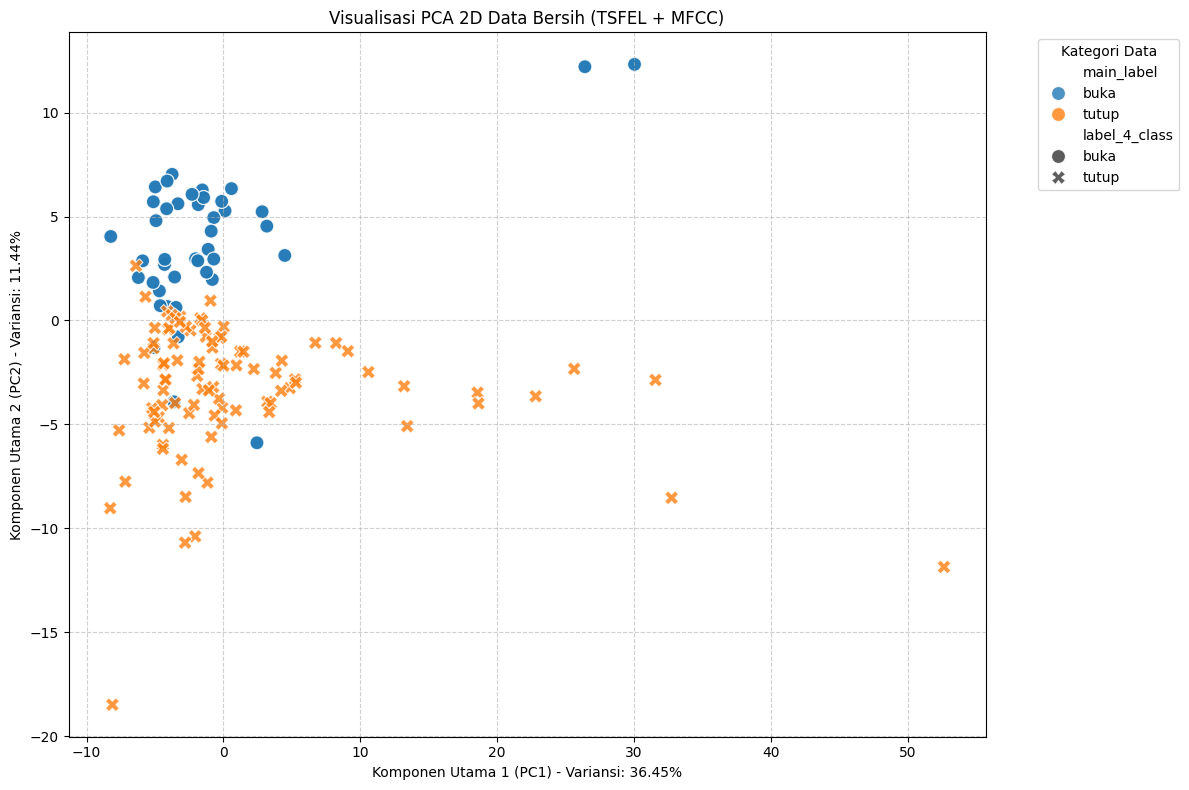


--- 4. Analisis Distribusi Label pada Data Bersih ---


/tmp/ipython-input-4080596998.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


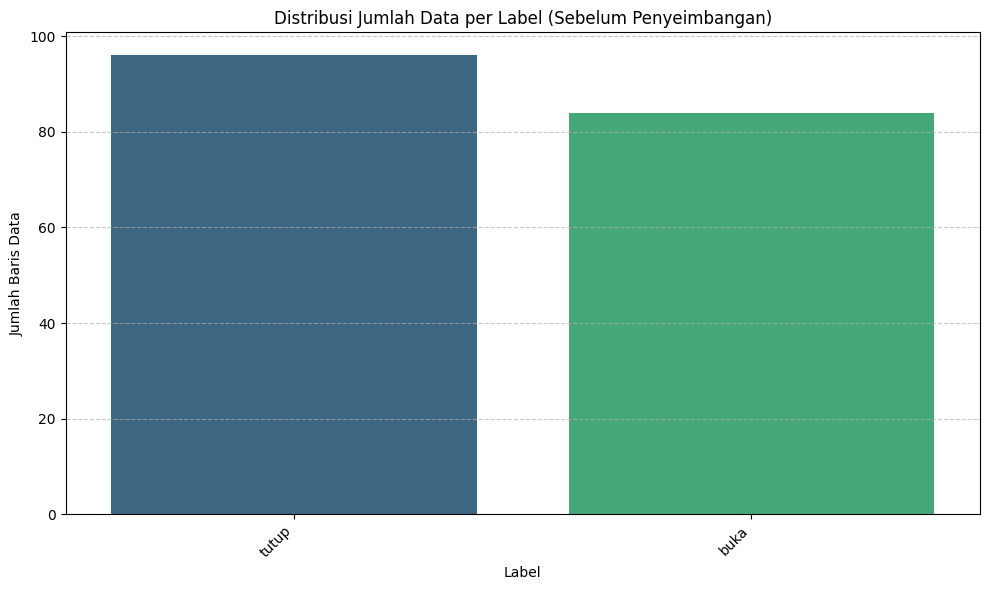


--- Ringkasan Jumlah Data per Label (Data Bersih) ---
label
tutup    96
buka     84
Name: count, dtype: int64

--- 5. Penyeimbangan Data (ADASYN) ---
Ukuran kelas terkecil: 84 sampel.
Menggunakan n_neighbors=5 untuk ADASYN/SMOTE.
Mencoba penyeimbangan dengan ADASYN...
⚠️ Peringatan: ADASYN gagal dengan error: No samples will be generated with the provided ratio settings.
   ADASYN tidak cocok untuk dataset ini. Beralih ke SMOTE.
✅ Berhasil diseimbangkan dengan SMOTE.

Total baris SETELAH penyeimbangan: 192

--- 6. Visualisasi Distribusi Label Setelah Penyeimbangan ---


/tmp/ipython-input-4080596998.py:207: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final_balanced['label'] = y_resampled_decoded
/tmp/ipython-input-4080596998.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


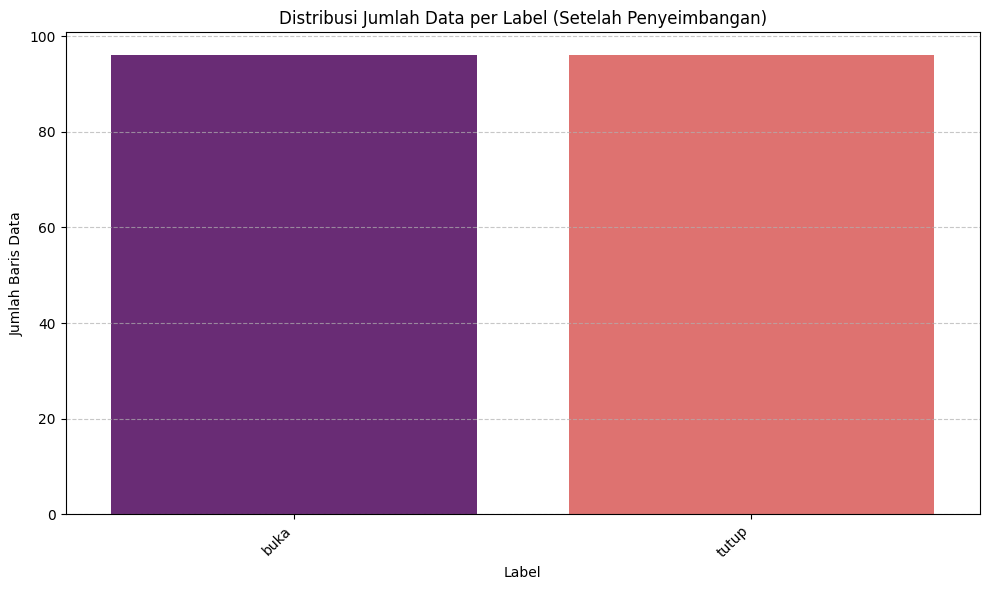


--- Ringkasan Jumlah Data per Label (Data Seimbang) ---
label
buka     96
tutup    96
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from IPython.display import display
# Impor untuk Penyeimbangan Data
from imblearn.over_sampling import ADASYN, SMOTE
from collections import Counter

# --- Asumsi: df_combined tersedia dari script sebelumnya (data_loader.py) ---
# Bagian simulasi ini akan dijalankan jika df_combined belum ada di memori.
try:
    if 'df_combined' not in locals() or df_combined.empty:
        # SIMULASI DATA DUMMY (DIPERBARUI DENGAN FITUR TSFEL + MFCC)
        print("Mencoba memuat data dummy untuk simulasi analisis karena 'df_combined' tidak ditemukan.")
        num_rows = 220
        df_combined = pd.DataFrame({
            'filename': [f'file_{i}.wav' for i in range(num_rows)],
            'label': np.random.choice(['buka.D', 'tutup.D', 'buka.M', 'tutup.M'], num_rows, p=[0.5, 0.2, 0.2, 0.1]),
            # Menggunakan nama fitur TSFEL asli (Contoh)
            'TS_MEAN': np.random.normal(10, 2, num_rows),
            'TS_STD': np.random.rand(num_rows) * 0.5,
            'TS_MAX': np.random.normal(20, 3, num_rows),
            # Menggunakan nama fitur MFCC (Contoh)
            'MFCC_Mean_1': np.random.normal(-5, 3, num_rows),
            'MFCC_Std_1': np.random.normal(1, 0.5, num_rows),
        })
        # Tambahkan nilai kosong dan outlier dummy
        df_combined.loc[10:15, 'TS_MEAN'] = np.nan
        df_combined.loc[190, 'TS_STD'] = 10.0 # Outlier
        df_combined.loc[200, 'TS_MAX'] = 100.0 # Outlier
except NameError:
    df_combined = pd.DataFrame() # Buat DataFrame kosong

if not df_combined.empty:

    # PERBAIKAN: Pastikan 'filename' dikecualikan dari fitur numerik
    non_numeric_cols = ['filename', 'label']
    numerical_features = [col for col in df_combined.columns if col not in non_numeric_cols]

    print(f"Total fitur numerik yang dianalisis: {len(numerical_features)} (TSFEL + MFCC)")

    # Buat salinan DataFrame untuk proses pembersihan
    df_processed = df_combined.copy()

    # =========================================================================
    # --- 1. Penanganan Nilai Kosong (Missing Values) dengan Imputasi Mean ---
    # =========================================================================
    print("\n--- 1. Penanganan Nilai Kosong (Imputasi Mean) ---")

    missing_data_cols = df_processed[numerical_features].isnull().sum()
    missing_data_cols = missing_data_cols[missing_data_cols > 0]

    if missing_data_cols.empty:
        print("✅ Tidak ada nilai kosong. Langkah Imputasi dilewati.")
    else:
        print("Kolom yang diimputasi (diisi rata-rata):")
        print(missing_data_cols)

        # Lakukan Imputasi Mean pada kolom numerik
        for col in missing_data_cols.index:
            if col in numerical_features: # Pastikan hanya imputasi kolom numerik
                mean_val = df_processed[col].mean()
                df_processed[col].fillna(mean_val, inplace=True)

        print(f"✅ Nilai kosong berhasil diatasi. Total baris: {len(df_processed)}")
        print(f"Pengecekan akhir nilai kosong: {df_processed[numerical_features].isnull().sum().sum()} (Seharusnya 0)")

    # =========================================================================
    # --- 2. Deteksi Outlier (LOF) dan Pembersihan Data ---
    # =========================================================================
    print("\n--- 2. Deteksi Outlier (Local Outlier Factor) dan Penghapusan ---")

    X_imputed = df_processed[numerical_features]

    # a. Scaling Data (Standarisasi)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    # b. Inisialisasi dan Terapkan LOF
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    y_pred_lof = lof.fit_predict(X_scaled) # -1 = Outlier, 1 = Inlier

    # Masukkan hasil LOF kembali ke DataFrame yang sudah diimputasi
    df_processed['is_outlier_lof'] = y_pred_lof

    outlier_count = (df_processed['is_outlier_lof'] == -1).sum()
    print(f"✅ LOF Selesai. Ditemukan {outlier_count} outlier.")

    # c. Penghapusan Outlier untuk mendapatkan Data Bersih
    # 'df_clean' adalah variabel PENTING untuk langkah selanjutnya
    df_clean = df_processed[df_processed['is_outlier_lof'] == 1].copy()

    rows_removed = len(df_processed) - len(df_clean)
    print(f"Jumlah baris yang dihapus (Outlier): {rows_removed}")
    print(f"Total baris Data Bersih (df_clean): {len(df_clean)}\n")

    # =========================================================================
    # --- 3. Visualisasi PCA Data Bersih (Clean Data) ---
    # =========================================================================
    print("--- 3. Visualisasi PCA 2D Data Bersih ---")

    X_clean_pca = df_clean[numerical_features]
    scaler_clean = StandardScaler()
    X_clean_scaled = scaler_clean.fit_transform(X_clean_pca)

    pca = PCA(n_components=2)
    X_pca_clean = pca.fit_transform(X_clean_scaled)

    df_plot_clean = pd.DataFrame(data=X_pca_clean, columns=['PC1', 'PC2'])
    df_plot_clean['label_4_class'] = df_clean['label'].values
    df_plot_clean['main_label'] = df_clean['label'].apply(lambda x: x.split('.')[0]).values

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot_clean,
        x='PC1',
        y='PC2',
        hue='main_label',   # Diwarnai berdasarkan 'buka' vs 'tutup'
        style='label_4_class', # Bentuk berdasarkan 4 kelas
        s=100,
        alpha=0.8
    )
    plt.title('Visualisasi PCA 2D Data Bersih (TSFEL + MFCC)')
    plt.xlabel(f'Komponen Utama 1 (PC1) - Variansi: {pca.explained_variance_ratio_[0]*100:.2f}%')
    plt.ylabel(f'Komponen Utama 2 (PC2) - Variansi: {pca.explained_variance_ratio_[1]*100:.2f}%')
    plt.legend(title='Kategori Data', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # --- 4. Visualisasi Distribusi Label & Daftar Kolom ---
    # =========================================================================
    print("\n--- 4. Analisis Distribusi Label pada Data Bersih ---")

    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=df_clean,
        x='label',
        order=df_clean['label'].value_counts().index,
        palette='viridis'
    )
    plt.title('Distribusi Jumlah Data per Label (Sebelum Penyeimbangan)')
    plt.xlabel('Label')
    plt.ylabel('Jumlah Baris Data')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\n--- Ringkasan Jumlah Data per Label (Data Bersih) ---")
    print(df_clean['label'].value_counts())

    # =========================================================================
    # --- 5. Penyeimbangan Data (ADASYN dengan Fallback ke SMOTE) ---
    # =========================================================================
    print("\n--- 5. Penyeimbangan Data (ADASYN) ---")

    X_clean = df_clean[numerical_features]
    y_clean_raw = df_clean['label']

    # a. Encoding Label
    le = LabelEncoder()
    y_clean_encoded = le.fit_transform(y_clean_raw)

    # b. Tentukan n_neighbors secara dinamis
    class_counts = Counter(y_clean_encoded)
    min_class_size = min(class_counts.values())

    if min_class_size <= 1:
        print(f"⚠️ Peringatan: Kelas terkecil memiliki {min_class_size} sampel. Penyeimbangan tidak dapat dilakukan.")
        df_final_balanced = df_clean.copy() # Gunakan data bersih apa adanya

    else:
        # Tentukan k_neighbors yang aman (tidak boleh > ukuran kelas terkecil)
        # Kita gunakan default 5, tapi jika kelas terkecil < 6, kita kurangi
        k_neighbors_safe = min(5, min_class_size - 1)

        print(f"Ukuran kelas terkecil: {min_class_size} sampel.")
        print(f"Menggunakan n_neighbors={k_neighbors_safe} untuk ADASYN/SMOTE.")

        try:
            # c. Coba ADASYN
            print("Mencoba penyeimbangan dengan ADASYN...")
            adasyn = ADASYN(random_state=42, n_neighbors=k_neighbors_safe)
            X_resampled, y_resampled_encoded = adasyn.fit_resample(X_clean, y_clean_encoded)
            print("✅ Berhasil diseimbangkan dengan ADASYN.")

        except (RuntimeError, ValueError) as e:
            # Menangkap error jika ADASYN gagal (seperti di riwayat chat kita)
            print(f"⚠️ Peringatan: ADASYN gagal dengan error: {e}")
            print("   ADASYN tidak cocok untuk dataset ini. Beralih ke SMOTE.")

            # d. Fallback ke SMOTE
            smote = SMOTE(random_state=42, k_neighbors=k_neighbors_safe)
            X_resampled, y_resampled_encoded = smote.fit_resample(X_clean, y_clean_encoded)
            print("✅ Berhasil diseimbangkan dengan SMOTE.")

        # e. Konversi kembali ke DataFrame
        y_resampled_decoded = le.inverse_transform(y_resampled_encoded)

        df_final_balanced = pd.DataFrame(X_resampled, columns=numerical_features)
        df_final_balanced['label'] = y_resampled_decoded

        print(f"\nTotal baris SETELAH penyeimbangan: {len(df_final_balanced)}")


    # =========================================================================
    # --- 6. Visualisasi Distribusi Label Setelah Penyeimbangan ---
    # =========================================================================
    print("\n--- 6. Visualisasi Distribusi Label Setelah Penyeimbangan ---")

    if 'df_final_balanced' in locals() and not df_final_balanced.empty:
        plt.figure(figsize=(10, 6))
        sns.countplot(
            data=df_final_balanced,
            x='label',
            order=df_final_balanced['label'].value_counts().index,
            palette='magma' # Palet berbeda agar terlihat baru
        )
        plt.title('Distribusi Jumlah Data per Label (Setelah Penyeimbangan)')
        plt.xlabel('Label')
        plt.ylabel('Jumlah Baris Data')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("\n--- Ringkasan Jumlah Data per Label (Data Seimbang) ---")
        print(df_final_balanced['label'].value_counts())

        # Variabel 'df_final_balanced' ini sekarang siap untuk skrip 'feature_selection_ig.py'

    else:
        print("⚠️ Tidak ada data seimbang untuk divisualisasikan (mungkin langkah 5 dilewati).")


else:
    print("❌ GAGAL: Variabel 'df_combined' tidak ditemukan atau kosong. Harap jalankan langkah pemuatan data sebelumnya terlebih dahulu.")

/tmp/ipython-input-3462105521.py:106: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_processed['is_outlier_lof'] = y_pred_lof


Data Bersih (df_clean) siap. Total baris: 360


#####################################################
--- 5. Penyeimbangan Data Menggunakan SMOTE & UNDERSAMPLING ---
#####################################################

[INFO] Data D-Group (buka.D, tutup.D) = 183 baris
[INFO] Data M-Group (buka.M, tutup.M) = 177 baris

--- Memproses Sub-Grup D-GROUP (buka.D vs tutup.D) ---
Menggunakan SMOTE dengan k_neighbors: 1 untuk menyeimbangkan sub-grup.
Sub-Grup D-GROUP (buka.D vs tutup.D) sebelum SMOTE: 183
Sub-Grup D-GROUP (buka.D vs tutup.D) setelah SMOTE: 194

--- Memproses Sub-Grup M-GROUP (buka.M vs tutup.M) ---
Menggunakan SMOTE dengan k_neighbors: 1 untuk menyeimbangkan sub-grup.
Sub-Grup M-GROUP (buka.M vs tutup.M) sebelum SMOTE: 177
Sub-Grup M-GROUP (buka.M vs tutup.M) setelah SMOTE: 182

--- Penyeimbangan Final (RandomUnderSampler) untuk semua 4 kelas ---
Menargetkan semua kelas ke jumlah sampel 91


/tmp/ipython-input-3462105521.py:160: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final_balanced['label'] = y_final_balanced
/tmp/ipython-input-3462105521.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(



Total baris SETELAH PENYEIMBANGAN FINAL: 364

--- 6. Visualisasi Distribusi Label Setelah Penyeimbangan Final ---


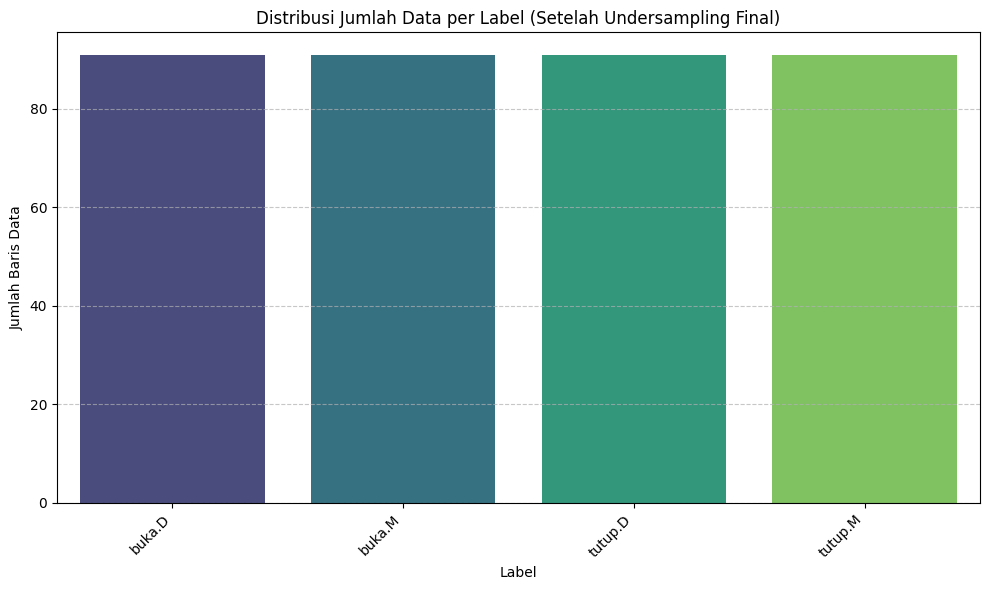


--- Ringkasan Jumlah Data per Label (Final Balanced) ---
label
buka.D     91
buka.M     91
tutup.D    91
tutup.M    91
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
# Menggunakan SMOTE untuk oversampling
from imblearn.over_sampling import SMOTE
# Menggunakan RandomUnderSampler untuk menyamakan semua kelas
from imblearn.under_sampling import RandomUnderSampler
from IPython.display import display

# --- Asumsi: df_combined tersedia dari script sebelumnya (data_loader.py) ---
try:
    if 'df_combined' not in locals() or df_combined.empty:
        # SIMULASI DATA DUMMY (untuk memastikan kode berjalan jika file sebelumnya belum dieksekusi)
        print("Mencoba memuat data dummy untuk simulasi analisis karena 'df_combined' tidak ditemukan.")
        num_rows = 400
        # Membuat data imbalanced
        df_combined = pd.DataFrame({
            'filename': [f'file_{i}.wav' for i in range(num_rows)],
            'label': np.random.choice(['buka.D', 'tutup.D', 'buka.M', 'tutup.M'], num_rows, p=[0.4, 0.3, 0.2, 0.1]),
            'feature_mean': np.random.normal(10, 2, num_rows),
            'feature_std': np.random.rand(num_rows) * 0.5,
            'feature_max': np.random.normal(20, 3, num_rows),
            'feature_kurtosis': np.random.normal(3, 1, num_rows) # Fitur tambahan
        })
        # Tambahkan nilai kosong dan outlier dummy
        df_combined.loc[10:15, 'feature_mean'] = np.nan
        df_combined.loc[390, 'feature_std'] = 10.0
        df_combined.loc[395, 'feature_max'] = 100.0
except NameError:
    df_combined = pd.DataFrame()

# --- FUNGSI HELPER UNTUK PENYEIMBANGAN SUB-GRUP ---
def balance_subgroup(df_sub, features, name):
    """Menerapkan Standard Scaler, Label Encoder, dan SMOTE pada sub-grup data."""
    print(f"\n--- Memproses Sub-Grup {name} ---")
    if df_sub.empty:
        print(f"Sub-Grup {name} kosong. Melewatkan penyeimbangan.")
        return None

    # 1. Pisahkan X dan y
    X_sub = df_sub[features].copy()
    y_raw_sub = df_sub['label'].values

    # 2. Scaling (Wajib, karena fitur digunakan dalam perhitungan jarak SMOTE)
    scaler_sub = StandardScaler()
    X_sub_scaled = scaler_sub.fit_transform(X_sub)

    # 3. Encoding Target (y)
    le_sub = LabelEncoder()
    y_encoded_sub = le_sub.fit_transform(y_raw_sub)

    # Hitung jumlah sampel minimum
    class_counts = pd.Series(y_encoded_sub).value_counts()
    min_samples = class_counts.min()

    # k_neighbors=1 adalah minimum yang diperlukan SMOTE.
    safe_k_neighbors = 1

    # 4. Terapkan SMOTE
    # SMOTE hanya dijalankan jika kelas-kelasnya belum seimbang di dalam sub-grup.
    if len(class_counts) > 1 and class_counts.max() != min_samples and min_samples > 1:
        print(f"Menggunakan SMOTE dengan k_neighbors: {safe_k_neighbors} untuk menyeimbangkan sub-grup.")
        smote = SMOTE(random_state=42, k_neighbors=safe_k_neighbors)
        X_resampled_sub, y_resampled_sub = smote.fit_resample(X_sub_scaled, y_encoded_sub)
        print(f"Sub-Grup {name} sebelum SMOTE: {len(X_sub)}")
        print(f"Sub-Grup {name} setelah SMOTE: {len(X_resampled_sub)}")
    else:
        # Jika sudah seimbang (seperti pada kasus Anda) atau tidak bisa di-SMOTE
        X_resampled_sub = X_sub_scaled
        y_resampled_sub = y_encoded_sub
        print(f"Sub-Grup {name} sudah seimbang atau tidak memerlukan SMOTE.")

    # 5. Konversi kembali ke nama label
    y_resampled_decoded_sub = le_sub.inverse_transform(y_resampled_sub)

    # 6. Gabungkan menjadi DataFrame
    df_resampled_sub = pd.DataFrame(X_resampled_sub, columns=features)
    df_resampled_sub['label'] = y_resampled_decoded_sub

    return df_resampled_sub

# =========================================================================
# --- ALUR UTAMA ---
# =========================================================================
if not df_combined.empty:

    non_numeric_cols = ['filename', 'label']
    numerical_features = [col for col in df_combined.columns if col not in non_numeric_cols]

    # 1 & 2. Pembersihan Data (Imputasi dan Penghapusan Outlier)

    # --- PEMBENTUKAN df_clean ---
    df_processed = df_combined.copy()
    for col in df_processed.select_dtypes(include=np.number).columns:
        df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

    X_imputed = df_processed[numerical_features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    y_pred_lof = lof.fit_predict(X_scaled)
    df_processed['is_outlier_lof'] = y_pred_lof
    df_clean = df_processed[df_processed['is_outlier_lof'] == 1].copy()
    df_clean.drop(columns=['is_outlier_lof'], inplace=True, errors='ignore')

    print(f"Data Bersih (df_clean) siap. Total baris: {len(df_clean)}")

    # =========================================================================
    # --- 5. Penyeimbangan Data (MULTI-STEP RESAMPLING) ---
    # =========================================================================
    print("\n\n#####################################################")
    print("--- 5. Penyeimbangan Data Menggunakan SMOTE & UNDERSAMPLING ---")
    print("#####################################################")

    # a. Filter Data Bersih ke dalam 2 Sub-Grup
    df_D = df_clean[df_clean['label'].str.contains(r'\.D$', regex=True)].copy()
    df_M = df_clean[df_clean['label'].str.contains(r'\.M$', regex=True)].copy()

    print(f"\n[INFO] Data D-Group (buka.D, tutup.D) = {len(df_D)} baris")
    print(f"[INFO] Data M-Group (buka.M, tutup.M) = {len(df_M)} baris")

    # b. Terapkan SMOTE pada masing-masing sub-grup (Jika diperlukan)
    df_D_resampled = balance_subgroup(df_D, numerical_features, "D-GROUP (buka.D vs tutup.D)")
    df_M_resampled = balance_subgroup(df_M, numerical_features, "M-GROUP (buka.M vs tutup.M)")

    # c. Gabungkan hasil resampled
    list_resampled = []
    if df_D_resampled is not None:
        list_resampled.append(df_D_resampled)
    if df_M_resampled is not None:
        list_resampled.append(df_M_resampled)

    if list_resampled:
        # Data yang digabungkan dari dua grup yang sudah seimbang secara internal (D dan M)
        df_combined_resampled = pd.concat(list_resampled, ignore_index=True)

        # d. PENYEIMBANGAN FINAL MENGGUNAKAN UNDERSAMPLING
        print("\n--- Penyeimbangan Final (RandomUnderSampler) untuk semua 4 kelas ---")

        # Pisahkan X dan y final
        X_final = df_combined_resampled.drop(columns=['label'])
        y_final = df_combined_resampled['label']

        # Hitung ukuran kelas minoritas di seluruh dataset yang akan menjadi target
        min_size = y_final.value_counts().min()
        target_counts = {label: min_size for label in y_final.unique()}

        print(f"Menargetkan semua kelas ke jumlah sampel {min_size}")

        # Terapkan RandomUnderSampler
        rus = RandomUnderSampler(sampling_strategy=target_counts, random_state=42)
        X_final_balanced, y_final_balanced = rus.fit_resample(X_final, y_final)

        # Gabungkan menjadi DataFrame final
        df_final_balanced = pd.DataFrame(X_final_balanced, columns=numerical_features)
        df_final_balanced['label'] = y_final_balanced

    else:
        df_final_balanced = pd.DataFrame()

    print(f"\n=====================================================")
    print(f"Total baris SETELAH PENYEIMBANGAN FINAL: {len(df_final_balanced)}")
    print(f"=====================================================")

    # =========================================================================
    # --- 6. Visualisasi Distribusi Label Setelah Penyeimbangan ---
    # =========================================================================
    if not df_final_balanced.empty:
        print("\n--- 6. Visualisasi Distribusi Label Setelah Penyeimbangan Final ---")

        # Visualisasi Jumlah Data per Label (Bar Plot)
        plt.figure(figsize=(10, 6))
        sns.countplot(
            data=df_final_balanced,
            x='label',
            order=df_final_balanced['label'].value_counts().index,
            palette='viridis'
        )
        plt.title('Distribusi Jumlah Data per Label (Setelah Undersampling Final)')
        plt.xlabel('Label')
        plt.ylabel('Jumlah Baris Data')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show() #

        print("\n--- Ringkasan Jumlah Data per Label (Final Balanced) ---")
        print(df_final_balanced['label'].value_counts())

    else:
        print("❌ GAGAL: Tidak ada data yang berhasil diseimbangkan dan digabungkan.")

else:
    print("❌ GAGAL: Variabel 'df_combined' tidak ditemukan atau kosong. Harap jalankan langkah pemuatan data sebelumnya terlebih dahulu.")

--- 1. Persiapan Data untuk Information Gain ---
Bentuk X (Fitur): (364, 156)
Bentuk y (Target): (364,)

--- 2. Menghitung Information Gain (Mutual Information) ---

--- 3. Peringkat Fitur Berdasarkan Information Gain ---


,Feature,Information_Gain_Score
70,0_Power bandwidth,0.944302
136,0_Wavelet entropy,0.911904
32,0_Autocorrelation,0.911524
121,0_Wavelet absolute mean_1714.29Hz,0.845887
71,0_Signal distance,0.784772
...,...,...
27,0_Root mean square,0.228580
29,0_Standard deviation,0.228580
5,0_ECDF Percentile_1,0.221885
18,0_Interquartile range,0.219651



--- 4. Visualisasi Information Gain ---


/tmp/ipython-input-381647069.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


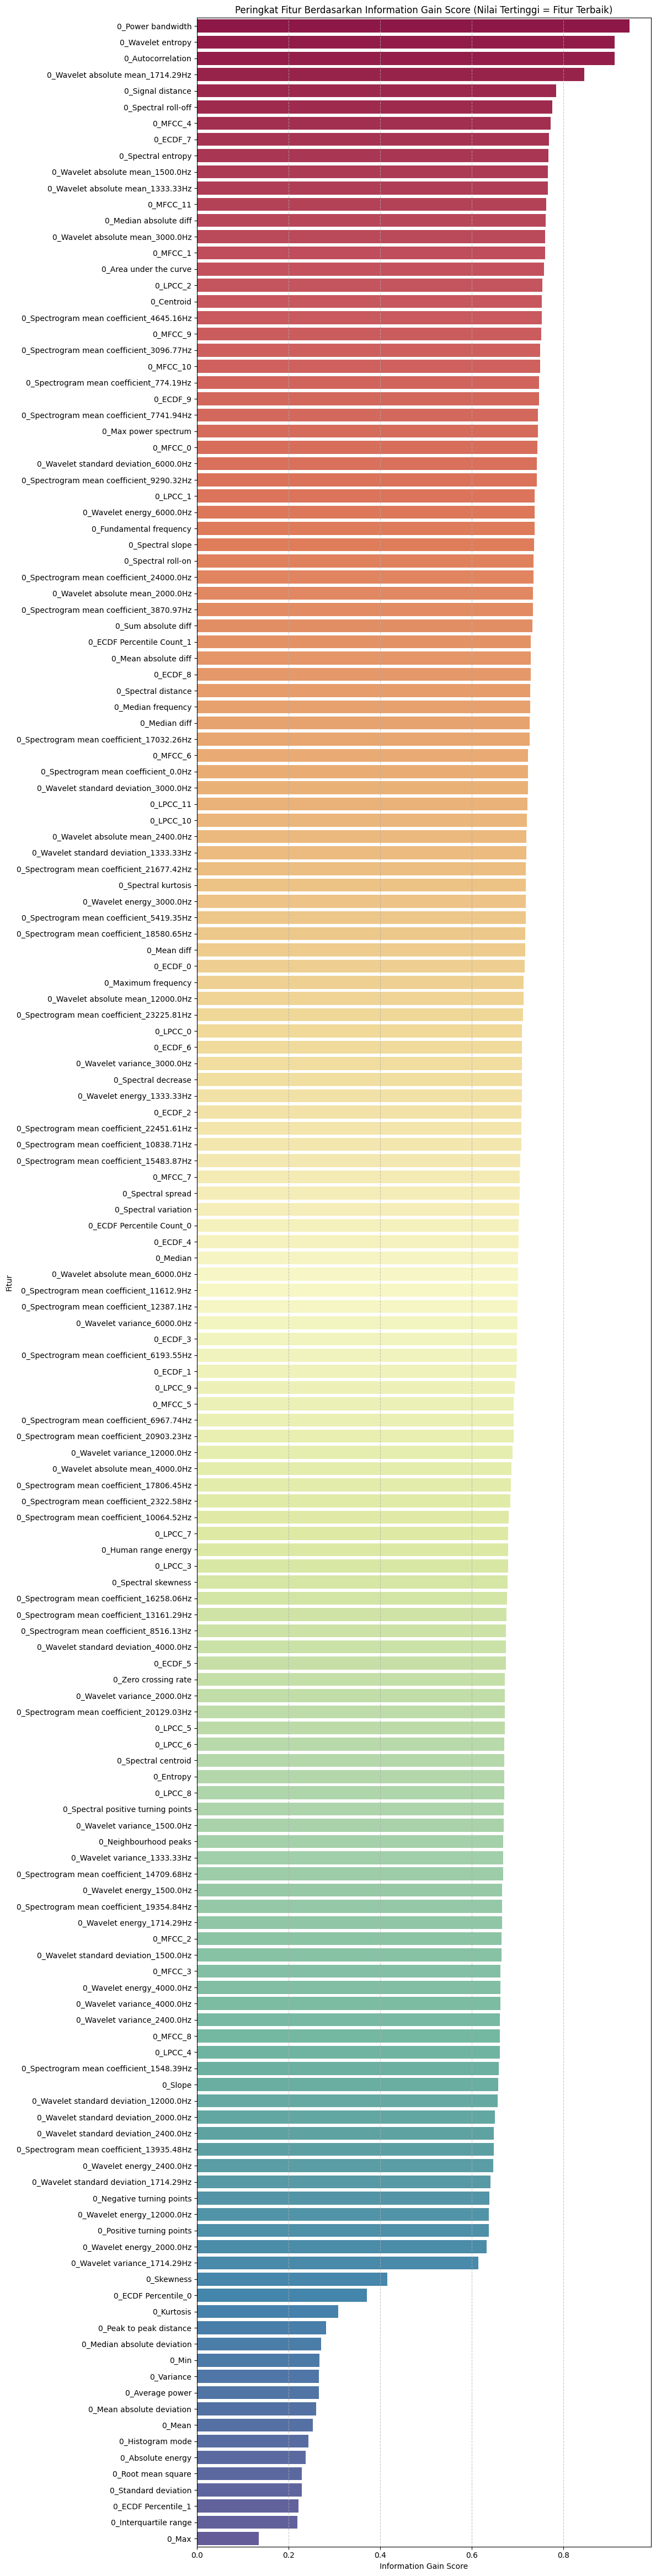

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from IPython.display import display
import matplotlib.pyplot as plt

# Pastikan variabel df_final_balanced ada dari sel sebelumnya
if 'df_final_balanced' in locals() and not df_final_balanced.empty:

    print("--- 1. Persiapan Data untuk Information Gain ---")

    # Information Gain (Mutual Information) memerlukan target (y) dalam bentuk numerik (encoded)

    # Pisahkan Fitur (X) dan Target (y)
    X = df_final_balanced.drop(columns=['label'])
    y_raw = df_final_balanced['label']

    # Encoding Target (y)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)

    print(f"Bentuk X (Fitur): {X.shape}")
    print(f"Bentuk y (Target): {y_encoded.shape}")

    # Pastikan data X tidak memiliki nilai NaN. Karena kita sudah bersihkannya, ini seharusnya aman.
    if X.isnull().sum().sum() > 0:
        print("⚠️ Peringatan: Data X masih mengandung nilai kosong. Melakukan imputasi mean darurat.")
        for col in X.columns:
            X[col] = X[col].fillna(X[col].mean())

    # --- 2. Hitung Information Gain ---
    print("\n--- 2. Menghitung Information Gain (Mutual Information) ---")

    # mutual_info_classif menghitung Information Gain antara setiap fitur (X) dan target (y).
    # Hasilnya adalah array skor, satu untuk setiap kolom di X.
    # Discretization: Defaultnya, ia mencoba mendiskritisasi data secara otomatis.
    ig_scores = mutual_info_classif(X, y_encoded, random_state=42)

    # --- 3. Buat dan Tampilkan DataFrame Hasil ---

    # Gabungkan skor dengan nama fitur
    feature_scores = pd.DataFrame({
        'Feature': X.columns,
        'Information_Gain_Score': ig_scores
    })

    # Urutkan berdasarkan skor tertinggi (fitur terbaik)
    feature_scores = feature_scores.sort_values(by='Information_Gain_Score', ascending=False)

    print("\n--- 3. Peringkat Fitur Berdasarkan Information Gain ---")
    display(feature_scores)

    # --- 4. Visualisasi Hasil ---
    print("\n--- 4. Visualisasi Information Gain ---")

    plt.figure(figsize=(12, max(6, len(feature_scores) * 0.3))) # Ukuran plot menyesuaikan jumlah fitur
    sns.barplot(
        x='Information_Gain_Score',
        y='Feature',
        data=feature_scores,
        palette='Spectral'
    )
    plt.title('Peringkat Fitur Berdasarkan Information Gain Score (Nilai Tertinggi = Fitur Terbaik)')
    plt.xlabel('Information Gain Score')
    plt.ylabel('Fitur')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("❌ GAGAL: Variabel 'df_final_balanced' tidak ditemukan atau kosong. Harap jalankan sel kode penyeimbangan data sebelumnya.")

--- 1. Persiapan Data untuk Information Gain ---
Bentuk X (Fitur): (192, 196)
Bentuk y (Target): (192,)

--- 2. Menghitung Information Gain (Mutual Information) ---

--- 3. Peringkat Fitur Berdasarkan Information Gain ---


,Feature,Information_Gain_Score
187,MFCC_Std_16,0.571799
177,MFCC_Std_11,0.539714
66,0_Power bandwidth,0.492077
136,0_Wavelet entropy,0.480462
2,0_Autocorrelation,0.474444
...,...,...
10,0_ECDF_1,0.032987
174,MFCC_Mean_10,0.030957
62,0_Negative turning points,0.009302
65,0_Positive turning points,0.006235



--- 4. Visualisasi Information Gain ---


/tmp/ipython-input-3944493795.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


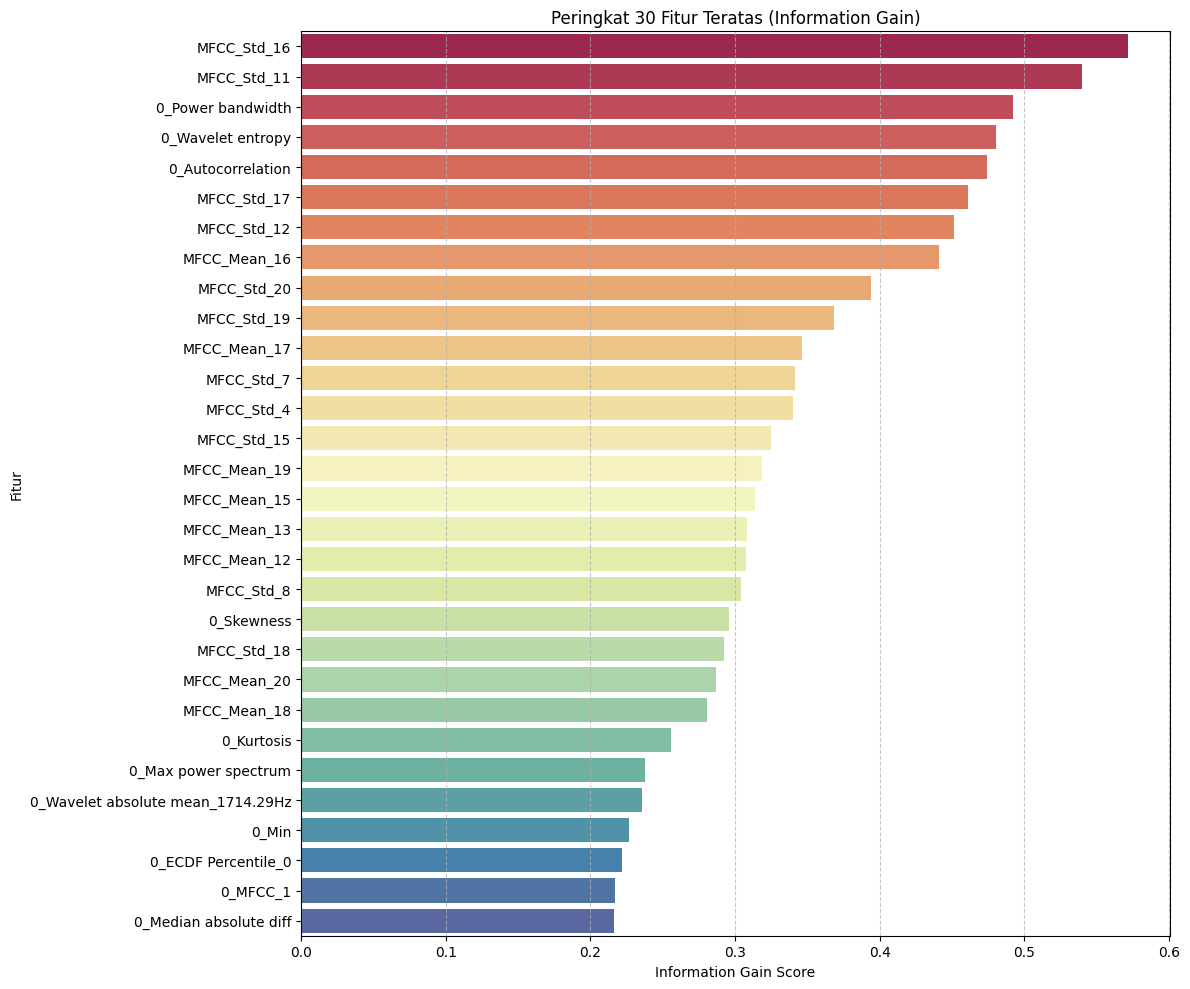

In [18]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns # Memastikan seaborn diimpor untuk plotting

# Pastikan variabel df_final_balanced ada dari sel sebelumnya
if 'df_final_balanced' in locals() and not df_final_balanced.empty:

    print("--- 1. Persiapan Data untuk Information Gain ---")

    # Information Gain (Mutual Information) memerlukan target (y) dalam bentuk numerik (encoded)

    # Pisahkan Fitur (X) dan Target (y)
    X = df_final_balanced.drop(columns=['label'])
    y_raw = df_final_balanced['label']

    # Encoding Target (y)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)

    print(f"Bentuk X (Fitur): {X.shape}")
    print(f"Bentuk y (Target): {y_encoded.shape}")

    # Pastikan data X tidak memiliki nilai NaN.
    # (Seharusnya sudah bersih dari analysis_and_outliers.py, tapi ini adalah jaring pengaman)
    if X.isnull().sum().sum() > 0:
        print("⚠️ Peringatan: Data X masih mengandung nilai kosong. Melakukan imputasi mean darurat.")
        for col in X.columns:
            if X[col].isnull().any(): # Hanya imputasi jika ada NaN
                X[col] = X[col].fillna(X[col].mean())

    # --- 2. Hitung Information Gain ---
    print("\n--- 2. Menghitung Information Gain (Mutual Information) ---")

    # mutual_info_classif menghitung Information Gain antara setiap fitur (X) dan target (y).
    ig_scores = mutual_info_classif(X, y_encoded, random_state=42)

    # --- 3. Buat dan Tampilkan DataFrame Hasil ---

    # Gabungkan skor dengan nama fitur
    feature_scores = pd.DataFrame({
        'Feature': X.columns,
        'Information_Gain_Score': ig_scores
    })

    # Urutkan berdasarkan skor tertinggi (fitur terbaik)
    feature_scores = feature_scores.sort_values(by='Information_Gain_Score', ascending=False)

    print("\n--- 3. Peringkat Fitur Berdasarkan Information Gain ---")
    display(feature_scores)

    # --- 4. Visualisasi Hasil ---
    print("\n--- 4. Visualisasi Information Gain ---")

    # Menentukan jumlah fitur yang akan ditampilkan di plot (misal, 30 teratas)
    # Menampilkan 196+ fitur sekaligus akan membuat plot tidak terbaca
    TOP_N_FEATURES = 30

    plt.figure(figsize=(12, 10)) # Ukuran plot yang wajar untuk 30 fitur
    sns.barplot(
        x='Information_Gain_Score',
        y='Feature',
        # Ambil 30 fitur teratas untuk visualisasi
        data=feature_scores.head(TOP_N_FEATURES),
        palette='Spectral'
    )
    plt.title(f'Peringkat {TOP_N_FEATURES} Fitur Teratas (Information Gain)')
    plt.xlabel('Information Gain Score')
    plt.ylabel('Fitur')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("❌ GAGAL: Variabel 'df_final_balanced' tidak ditemukan atau kosong. Harap jalankan sel kode penyeimbangan data sebelumnya.")

Fitur yang digunakan: ['0_Absolute energy', '0_Average power', '0_ECDF Percentile Count_0', '0_ECDF Percentile Count_1', '0_ECDF Percentile_0', '0_ECDF Percentile_1', '0_ECDF_0', '0_ECDF_1', '0_ECDF_2', '0_ECDF_3', '0_ECDF_4', '0_ECDF_5', '0_ECDF_6', '0_ECDF_7', '0_ECDF_8', '0_ECDF_9', '0_Entropy', '0_Histogram mode', '0_Interquartile range', '0_Kurtosis', '0_Max', '0_Mean', '0_Mean absolute deviation', '0_Median', '0_Median absolute deviation', '0_Min', '0_Peak to peak distance', '0_Root mean square', '0_Skewness', '0_Standard deviation', '0_Variance', '0_Area under the curve', '0_Autocorrelation', '0_Centroid', '0_Fundamental frequency', '0_Human range energy', '0_LPCC_0', '0_LPCC_1', '0_LPCC_10', '0_LPCC_11', '0_LPCC_2', '0_LPCC_3', '0_LPCC_4', '0_LPCC_5', '0_LPCC_6', '0_LPCC_7', '0_LPCC_8', '0_LPCC_9', '0_MFCC_0', '0_MFCC_1', '0_MFCC_10', '0_MFCC_11', '0_MFCC_2', '0_MFCC_3', '0_MFCC_4', '0_MFCC_5', '0_MFCC_6', '0_MFCC_7', '0_MFCC_8', '0_MFCC_9', '0_Max power spectrum', '0_Maximum f

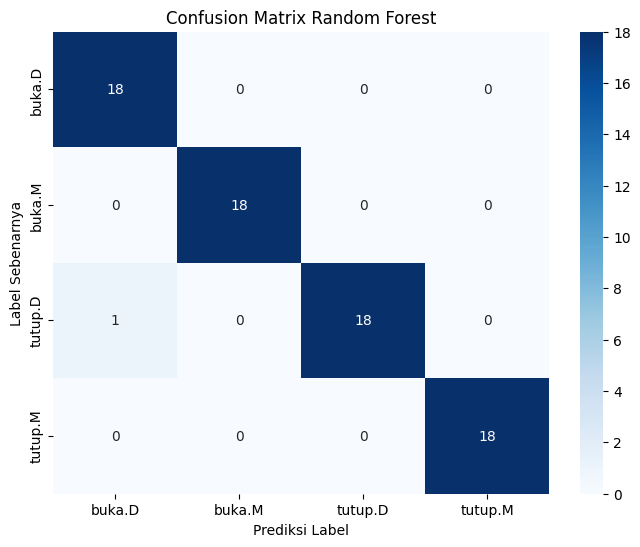


✅ Semua file berhasil disimpan:
- random_forest_model.joblib
- label_encoder.joblib
- scaler.joblib
- imputer.joblib
- feature_columns.joblib (kolom urutan fitur)


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Simulasi Data ---
try:
    if 'df_final_balanced' not in locals() or df_final_balanced.empty:
        print("Mencoba memuat data dummy untuk simulasi pelatihan model...")
        n_samples_per_class = 91
        n_total_samples = 4 * n_samples_per_class
        df_final_balanced = pd.DataFrame({
            'label': (['buka.D'] * n_samples_per_class +
                      ['tutup.D'] * n_samples_per_class +
                      ['buka.M'] * n_samples_per_class +
                      ['tutup.M'] * n_samples_per_class),
            'feature_mean': np.random.normal(10, 2, n_total_samples) + np.tile([0, 5, 0, 5], n_samples_per_class),
            'feature_std': np.random.rand(n_total_samples) * 0.5,
            'feature_max': np.random.normal(20, 3, n_total_samples),
            'feature_kurtosis': np.random.normal(3, 1, n_total_samples)
        })
        df_final_balanced.loc[10:15, 'feature_mean'] = np.nan
except NameError:
    df_final_balanced = pd.DataFrame()

if not df_final_balanced.empty:

    # --- 2. Tentukan fitur terbaik (atau hasil Information Gain) ---
    numerical_features = df_final_balanced.drop(columns=['label']).columns.tolist()
    TOP_FEATURES = numerical_features
    print(f"Fitur yang digunakan: {TOP_FEATURES}")

    # --- 3. Persiapan data ---
    X_raw = df_final_balanced[TOP_FEATURES]
    y = df_final_balanced['label']

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    imputer = SimpleImputer(strategy='mean')
    imputer.fit(X_train_raw)

    X_train_imputed = imputer.transform(X_train_raw)
    X_test_imputed = imputer.transform(X_test_raw)

    scaler = StandardScaler()
    scaler.fit(X_train_imputed)

    X_train_scaled = scaler.transform(X_train_imputed)
    X_test_scaled = scaler.transform(X_test_imputed)

    X_train = pd.DataFrame(X_train_scaled, columns=TOP_FEATURES)
    X_test = pd.DataFrame(X_test_scaled, columns=TOP_FEATURES)

    # --- 4. Training Model ---
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    print("✅ Pelatihan model Random Forest selesai.")

    # --- 5. Evaluasi ---
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Akurasi pada Data Uji: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Confusion Matrix Random Forest')
    plt.xlabel('Prediksi Label')
    plt.ylabel('Label Sebenarnya')
    plt.show()

    # --- 6. Simpan komponen untuk Streamlit ---
    joblib.dump(rf_model, 'random_forest_model.joblib')
    joblib.dump(le, 'label_encoder.joblib')
    joblib.dump(scaler, 'scaler.joblib')
    joblib.dump(imputer, 'imputer.joblib')
    joblib.dump(TOP_FEATURES, 'feature_columns.joblib')  # 🔹 Tambahan penting

    print("\n✅ Semua file berhasil disimpan:")
    print("- random_forest_model.joblib")
    print("- label_encoder.joblib")
    print("- scaler.joblib")
    print("- imputer.joblib")
    print("- feature_columns.joblib (kolom urutan fitur)")
else:
    print("❌ Data tidak ditemukan. Jalankan data balancing dan feature selection terlebih dahulu.")


--- 2. Mempersiapkan Model Menggunakan 30 Fitur Teratas ---
['MFCC_Std_16', 'MFCC_Std_11', '0_Power bandwidth', '0_Wavelet entropy', '0_Autocorrelation', 'MFCC_Std_17', 'MFCC_Std_12', 'MFCC_Mean_16', 'MFCC_Std_20', 'MFCC_Std_19', 'MFCC_Mean_17', 'MFCC_Std_7', 'MFCC_Std_4', 'MFCC_Std_15', 'MFCC_Mean_19', 'MFCC_Mean_15', 'MFCC_Mean_13', 'MFCC_Mean_12', 'MFCC_Std_8', '0_Skewness', 'MFCC_Std_18', 'MFCC_Mean_20', 'MFCC_Mean_18', '0_Kurtosis', '0_Max power spectrum', '0_Wavelet absolute mean_1714.29Hz', '0_Min', '0_ECDF Percentile_0', '0_MFCC_1', '0_Median absolute diff']

Bentuk data latih (raw): (153, 30)
Bentuk data uji (raw): (39, 30)

--- 5. Memulai Pelatihan Model Random Forest ---
✅ Pelatihan model Random Forest selesai.

--- 6. Evaluasi Model pada Data Uji ---
Akurasi pada Data Uji: 1.0000

Laporan Klasifikasi:
              precision    recall  f1-score   support

        buka       1.00      1.00      1.00        20
       tutup       1.00      1.00      1.00        19

    accurac

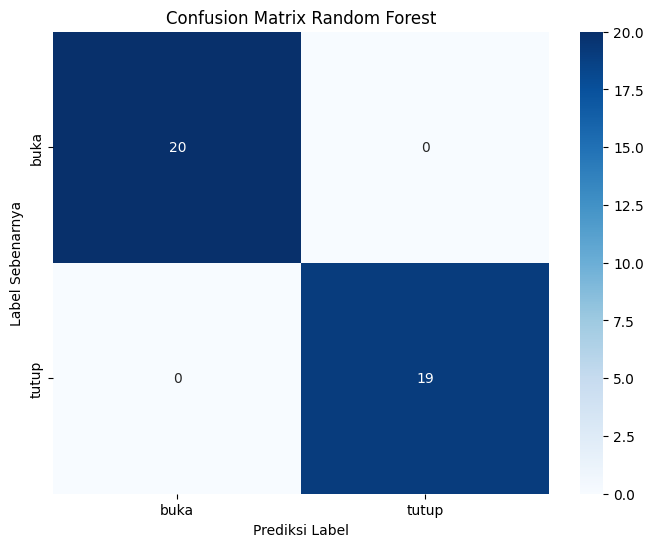


--- 7. Menyimpan Komponen Model untuk Streamlit ---

✅ Semua file berhasil disimpan:
- random_forest_model.joblib (Model)
- label_encoder.joblib (Encoder Label)
- scaler.joblib (Standard Scaler)
- imputer.joblib (Simple Imputer)
- feature_columns.joblib (Daftar Kolom Fitur)


In [19]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Simulasi Data (Jika Variabel Tidak Ditemukan) ---
try:
    if 'df_final_balanced' not in locals() or df_final_balanced.empty:
        print("Mencoba memuat data dummy (df_final_balanced)...")
        n_samples_per_class = 91
        n_total_samples = 4 * n_samples_per_class
        df_final_balanced = pd.DataFrame({
            'label': (['buka.D'] * n_samples_per_class +
                      ['tutup.D'] * n_samples_per_class +
                      ['buka.M'] * n_samples_per_class +
                      ['tutup.M'] * n_samples_per_class),
            'TS_MEAN': np.random.normal(10, 2, n_total_samples),
            'MFCC_Mean_1': np.random.rand(n_total_samples) * 0.5,
            'Spectral_Entropy': np.random.normal(20, 3, n_total_samples),
            'Zero_Crossing_Rate': np.random.normal(3, 1, n_total_samples)
        })
        df_final_balanced.loc[10:15, 'TS_MEAN'] = np.nan

    if 'feature_scores' not in locals() or feature_scores.empty:
        print("Mencoba memuat data dummy (feature_scores)...")
        # Ambil fitur dari simulasi df_final_balanced
        sim_features = df_final_balanced.drop(columns=['label']).columns.tolist()
        feature_scores = pd.DataFrame({
            'Feature': sim_features,
            'Information_Gain_Score': np.random.rand(len(sim_features))
        }).sort_values(by='Information_Gain_Score', ascending=False)

except NameError:
    df_final_balanced = pd.DataFrame()
    feature_scores = pd.DataFrame()

if not df_final_balanced.empty and not feature_scores.empty:

    # =========================================================================
    # --- 2. Tentukan Fitur Terbaik (Berdasarkan Information Gain) ---
    # =========================================================================

    # Tentukan berapa banyak fitur teratas yang ingin Anda gunakan
    N_FEATURES_TO_USE = 30

    # Ambil daftar N fitur teratas dari hasil Information Gain
    TOP_FEATURES = feature_scores.head(N_FEATURES_TO_USE)['Feature'].tolist()

    print(f"--- 2. Mempersiapkan Model Menggunakan {len(TOP_FEATURES)} Fitur Teratas ---")
    print(TOP_FEATURES)

    # =========================================================================
    # --- 3. Persiapan Data (Hanya Menggunakan Fitur Teratas) ---
    # =========================================================================

    # Filter df_final_balanced HANYA untuk fitur-fitur terbaik
    X_raw = df_final_balanced[TOP_FEATURES]
    y = df_final_balanced['label']

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"\nBentuk data latih (raw): {X_train_raw.shape}")
    print(f"Bentuk data uji (raw): {X_test_raw.shape}")

    # =========================================================================
    # --- 4. Fitting Preprocessors (Imputer & Scaler) ---
    # =========================================================================

    # a. Imputer (Menangani NaN)
    imputer = SimpleImputer(strategy='mean')
    imputer.fit(X_train_raw) # Fit HANYA pada data latih

    X_train_imputed = imputer.transform(X_train_raw)
    X_test_imputed = imputer.transform(X_test_raw)

    # b. Scaler (Normalisasi)
    scaler = StandardScaler()
    scaler.fit(X_train_imputed) # Fit HANYA pada data latih

    X_train_scaled = scaler.transform(X_train_imputed)
    X_test_scaled = scaler.transform(X_test_imputed)

    # (Opsional) Konversi kembali ke DataFrame untuk kemudahan
    X_train = pd.DataFrame(X_train_scaled, columns=TOP_FEATURES)
    X_test = pd.DataFrame(X_test_scaled, columns=TOP_FEATURES)

    # =========================================================================
    # --- 5. Pelatihan Model Random Forest ---
    # =========================================================================
    print("\n--- 5. Memulai Pelatihan Model Random Forest ---")

    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1 # Gunakan semua core
    )
    rf_model.fit(X_train, y_train)
    print("✅ Pelatihan model Random Forest selesai.")

    # =========================================================================
    # --- 6. Evaluasi Model ---
    # =========================================================================
    print("\n--- 6. Evaluasi Model pada Data Uji ---")

    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Akurasi pada Data Uji: {acc:.4f}")

    print("\nLaporan Klasifikasi:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Confusion Matrix Random Forest')
    plt.xlabel('Prediksi Label')
    plt.ylabel('Label Sebenarnya')
    plt.show()

    # =========================================================================
    # --- 7. Simpan SEMUA Komponen untuk Streamlit ---
    # =========================================================================

    print("\n--- 7. Menyimpan Komponen Model untuk Streamlit ---")

    joblib.dump(rf_model, 'random_forest_model.joblib')
    joblib.dump(le, 'label_encoder.joblib')
    joblib.dump(scaler, 'scaler.joblib')
    joblib.dump(imputer, 'imputer.joblib')
    joblib.dump(TOP_FEATURES, 'feature_columns.joblib') # 🔹 Menyimpan daftar fitur

    print("\n✅ Semua file berhasil disimpan:")
    print("- random_forest_model.joblib (Model)")
    print("- label_encoder.joblib (Encoder Label)")
    print("- scaler.joblib (Standard Scaler)")
    print("- imputer.joblib (Simple Imputer)")
    print("- feature_columns.joblib (Daftar Kolom Fitur)")

else:
    print("❌ GAGAL: Variabel 'df_final_balanced' atau 'feature_scores' tidak ditemukan. Harap jalankan sel kode sebelumnya.")

## Evaluasi
dari hasil prediksi semua data bergantung pada fitur statistik sehingga suara tidak menemukan pembeda yang membuat model selalu memprediksi buka

link dataset
https://drive.google.com/drive/folders/16e80DwDgUzjX7d69ZZwuWDMYGxYQM31j?usp=sharing

link website

https://prediksisuara.streamlit.app/

# Task
Prepare data for binary classification by creating a `main_label` column in `df_final_balanced` (grouping 'buka.D', 'buka.M' into 'buka' and 'tutup.D', 'tutup.M' into 'tutup'), then apply Linear Discriminant Analysis (LDA) to the numerical features using `main_label` as the target, and finally, visualize the LDA results with a 2D scatter plot colored by `main_label` to assess class separability.

## Prepare Data for Binary Classification

### Subtask:
Create a new binary 'main_label' column in `df_final_balanced` by grouping 'buka.D' and 'buka.M' into 'buka', and 'tutup.D' and 'tutup.M' into 'tutup'. This new binary label will be used as the target for dimensionality reduction techniques focused on binary classification.


**Reasoning**:
To prepare the data for binary classification, I will create a new 'main_label' column by mapping the existing granular labels ('buka.D', 'buka.M', 'tutup.D', 'tutup.M') into binary categories ('buka' and 'tutup'). Then, I will display the value counts to confirm the new column's distribution.

